<a href="https://colab.research.google.com/github/jenelaineDC/DSML-PROJECTS/blob/main/Online%20Retail/Online_Retail_Analytics_K_Means_Clustering_%26_Apriori.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### BACKGROUND

In today’s competitive e-commerce environment, many small online retailers and new entrants face challenges in adopting data-driven strategies for customer retention and growth. While customer-centric marketing and data mining are increasingly critical, businesses often lack the technical expertise to implement these practices effectively.

This project uses the Online Retail II dataset, which contains transactional records from a UK-based non-store retailer that primarily sells unique all-occasion giftware between December 2009 and December 2011. Many of the company’s customers are wholesalers, making it important to understand both individual and bulk-buying behaviors.

By leveraging data science techniques, this project aims to uncover actionable insights into customer behavior and product purchasing patterns. The analysis focuses on customer segmentation through the RFM (Recency, Frequency, Monetary) model using K-Means clustering, as well as Market Basket Analysis (MBA) using the Apriori algorithm. Together, these approaches provide a foundation for customer relationship management (CRM), targeted marketing, inventory optimization, and cross-selling strategies.


### PROJECT GOAL

The main goals of this project are:
- Customer Segmentation (K-Means with RFM): The project aims to segment customers into meaningful groups to support targeted marketing and CRM strategies. By analyzing recency, frequency, and monetary values, we can identify loyal customers, at-risk customers, and other groups that allow for tailored engagement and more effective retention strategies.

- Product & Sales Insights: Another key objective is to analyze product and sales performance. This includes identifying top-selling products to guide inventory planning and pricing adjustments, detecting return/refund trends that may negatively impact sales, and uncovering seasonality and revenue patterns across time periods and countries to better understand customer demand.

- Market Basket Analysis (MBA): Finally, the project applies the Apriori algorithm to discover associations between products frequently purchased together. These insights can be leveraged to design cross-selling and upselling strategies, as well as to inform product recommendation systems that enhance the overall customer experience.

### SCOPE AND LIMITATION
The project will:
- Use the Online Retail II dataset (2009–2011), focusing only on the variables provided.
- Perform customer segmentation using RFM modeling combined with K-Means clustering.
- Conduct Market Basket Analysis (MBA) with the Apriori algorithm to identify product affinities and purchasing patterns.

The project will not:
- Incorporate external data sources such as competitor activity or macroeconomic conditions.
- Generalize findings beyond this specific retailer, as results are limited to a single dataset.
- Deploy models into production; instead, it will focus on generating insights and analytical frameworks for potential business use.
- Capture all product categories or customer behaviors, since the dataset is time-bound and may not fully represent long-term patterns.



#### SET-UP

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/DSML PROJECTS/Online Retail

/content/drive/MyDrive/DSML PROJECTS/Online Retail


In [3]:
!pip install lifetimes

In [4]:
# for operational packages
import pandas as pd
import numpy as np

# for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# for column display
pd.set_option('display.max_columns', None)

# for unsupervised learning modeling
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# for BG/NBD and Gamma-gamma model
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import calibration_and_holdout_data, summary_data_from_transaction_data, calculate_alive_path
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix, \
  plot_period_transactions, plot_history_alive, plot_cumulative_transactions, \
  plot_calibration_purchases_vs_holdout_purchases, plot_transaction_rate_heterogeneity, \
  plot_dropout_rate_heterogeneity

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

### DATA DEVELOPMENT PROCESS

#### Data Source

The Online Retail II dataset contains 541,909 transaction records from a UK-based and registered non-store online retailer, covering the period between 01/12/2009 and 09/12/2011. The company primarily sells unique, all-occasion giftware, with a significant portion of its customers being wholesalers.

[UC Irvene Machine Learning Repository](https://archive.ics.uci.edu/dataset/502/online+retail+ii)

| Variable     | Description                                                                 |
|--------------|-----------------------------------------------------------------------------|
| InvoiceNo    | Unique invoice number (6-digit). If it starts with 'C', it indicates a cancellation. |
| StockCode    | Unique product (item) code (5-digit) assigned to each distinct product.      |
| Description  | Name of the product (item).                                                  |
| Quantity     | Number of units of the product per transaction. Numeric.                     |
| InvoiceDate  | Date and time when the transaction was generated.                            |
| UnitPrice    | Unit price of the product in sterling (£). Numeric.                          |
| CustomerID   | Unique customer identifier (5-digit).                                        |
| Country      | Name of the country where the customer resides.                              |


In [5]:
df = pd.read_csv('data.csv', encoding='ISO-8859-1')

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [9]:
df.describe(include = 'O')

,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/2011 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


#### Data Preprocessing

##### Missing Values CustomerID & Description

In [10]:
# Count missing Values per column
df.isna().sum().sort_values(ascending = False)

,0
CustomerID,135080
Description,1454
StockCode,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0


In [11]:
df[df['CustomerID'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,12/9/2011 10:26,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,12/9/2011 10:26,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,12/9/2011 10:26,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,12/9/2011 10:26,10.79,NaN,United Kingdom


In [12]:
df[df['Description'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,12/7/2011 18:26,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,12/7/2011 18:31,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,12/7/2011 18:35,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom


In [13]:
df[(df['Description'].isna()) & (df['CustomerID'].isna())]
print('No of Na in Description: ', df[df['Description'].isna()].shape[0])
print('No of Na in both Description and Customer ID: ', df[(df['Description'].isna()) & (df['CustomerID'].isna())].shape[0])
print('No of Na in Description and UnitPrice equal 0: ', df[(df['Description'].isna()) & (df['UnitPrice'] == 0)].shape[0])

No of Na in Description:  1454
No of Na in both Description and Customer ID:  1454
No of Na in Description and UnitPrice equal 0:  1454


##### Datetime Format: InvoiceDate

In [14]:
# Convert InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [15]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

##### Negative Values: Quantity and UnitPrice

- For column `Quantity` there is an observed 10624 rows of negative values. Consequently, the Invoice No started with letter C. Based on the dataset description the C pertains to order cancellation. Upon checking we have 9288 cancelled transaction and all of this cancelled transaction have negative quantities.

- There are only two entries with negative `UnitPrice`. However, its invoice number starts with A with a stockcode of B. In our datacard stockcode is a 5 digit number.

In [16]:
# Check data with negative Quantity
df[df['Quantity'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [17]:
print('No of Cancelled Transaction: ', df[df["InvoiceNo"].str.startswith("C")].shape[0])
print('No of Cancelled Transaction with Negative Quantities: ', df[df["InvoiceNo"].str.startswith("C")][df['Quantity'] < 0].shape[0])

No of Cancelled Transaction:  9288
No of Cancelled Transaction with Negative Quantities:  9288


/tmp/ipython-input-1677812694.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print('No of Cancelled Transaction with Negative Quantities: ', df[df["InvoiceNo"].str.startswith("C")][df['Quantity'] < 0].shape[0])


In [18]:
# Check data with negative UnitPrice
df[df['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [19]:
df[df['UnitPrice'] == 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom
538554,581408,85175,NaN,20,2011-12-08 14:06:00,0.0,NaN,United Kingdom


In [20]:
df[(df['UnitPrice'] == 0) & (df['CustomerID'].isna())]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom
538554,581408,85175,NaN,20,2011-12-08 14:06:00,0.0,NaN,United Kingdom


##### Invoice

Based on the data desription, the Invoice number is a unique 6 digit code, however we want to check if there are other unique values present in the data.
    
    - C pertains to Cancellation.
    - A might be accounting adjustment.

In [21]:
df["InvoiceNo"] = df["InvoiceNo"].astype("str")
df[df["InvoiceNo"].str.match("^\\d{6}$") == False]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [22]:
df["InvoiceNo"].str.replace("[0-9]", "", regex=True).unique()

array(['', 'C', 'A'], dtype=object)

In [23]:
df[df["InvoiceNo"].str.startswith("A")]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


##### Stockcode
Based on the data description, the Stock code is a unique 5 digit number. However we are observing values that does not conform to this 5 digit number. There are 33 other stockcode format.

In [24]:
# Convert Stockcode to String
df["StockCode"] = df["StockCode"].astype("str")

# Display data that does not conform with the 5 digit value
df[(df["StockCode"].str.match("^\\d{5}$") == False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00,18.00,12583.0,France
...,...,...,...,...,...,...,...,...
541778,581578,84997C,CHILDRENS CUTLERY POLKADOT BLUE,8,2011-12-09 12:16:00,4.15,12713.0,Germany
541809,581579,85099C,JUMBO BAG BAROQUE BLACK WHITE,10,2011-12-09 12:19:00,1.79,17581.0,United Kingdom
541838,581580,84993A,75 GREEN PETIT FOUR CASES,2,2011-12-09 12:20:00,0.42,12748.0,United Kingdom
541844,581580,85049A,TRADITIONAL CHRISTMAS RIBBONS,1,2011-12-09 12:20:00,1.25,12748.0,United Kingdom


In [25]:
# Show unique values of Stockcode
df[(df["StockCode"].str.match("^\\d{5}$") == False) & (df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") == False)]["StockCode"].unique()

# The regex function after the ampersand looks for value with letters from small a-z and capital a-z.
# The + sign indicates that more than one letter can exist

array(['POST', 'D', 'C2', 'DOT', 'M', 'BANK CHARGES', 'S', 'AMAZONFEE',
       'DCGS0076', 'DCGS0003', 'gift_0001_40', 'DCGS0070', 'm',
       'gift_0001_50', 'gift_0001_30', 'gift_0001_20', 'DCGS0055',
       'DCGS0072', 'DCGS0074', 'DCGS0069', 'DCGS0057', 'DCGSSBOY',
       'DCGSSGIRL', 'gift_0001_10', 'PADS', 'DCGS0004', 'DCGS0073',
       'DCGS0071', 'DCGS0068', 'DCGS0067', 'DCGS0066P', 'B', 'CRUK'],
      dtype=object)

In [26]:
otherstockcode = ['POST', 'D', 'C2', 'DOT', 'M', 'BANK CHARGES', 'S', 'AMAZONFEE',
       'DCGS0076', 'DCGS0003', 'gift_0001_40', 'DCGS0070', 'm',
       'gift_0001_50', 'gift_0001_30', 'gift_0001_20', 'DCGS0055',
       'DCGS0072', 'DCGS0074', 'DCGS0069', 'DCGS0057', 'DCGSSBOY',
       'DCGSSGIRL', 'gift_0001_10', 'PADS', 'DCGS0004', 'DCGS0073',
       'DCGS0071', 'DCGS0068', 'DCGS0067', 'DCGS0066P', 'B', 'CRUK']

In [27]:
# Check description of the other stockcode
df[df['StockCode'].isin(otherstockcode)].drop_duplicates(subset='StockCode', keep='first')[['StockCode', 'Description']]

,StockCode,Description
45,POST,POSTAGE
141,D,Discount
1423,C2,CARRIAGE
1814,DOT,DOTCOM POSTAGE
2239,M,Manual
4406,BANK CHARGES,Bank Charges
14436,S,SAMPLES
14514,AMAZONFEE,AMAZON FEE
21326,DCGS0076,SUNJAR LED NIGHT NIGHT LIGHT
24906,DCGS0003,BOXED GLASS ASHTRAY


##### Data Cleaning

- [X] Drop Cancelled Transaction based on column `InvoiceNo` which starts with letter C and letter A
- [X] Drop NA values in column `Description` and `CustomerID`
- [X] Drop negative values and zero values in column `Quantity`
- [X] Drop negative values and zero values in column `UnitPrice`
- [X] Remove duplicate entries
- [X] Remove rows with `Stockcode` equal to PADS

In [28]:
# Drop invoiceno that starts with C and A
df = df[df['InvoiceNo'].str.match("^\\d{6}$") == True]

In [29]:
# Drop missing values in Description and Customer ID
df.dropna(subset = ['Description', 'CustomerID'], inplace = True)

In [30]:
# Drop negative and zero values in Quantity
df = df[df['Quantity'] > 0]

In [31]:
# Drop negative and zero values in UnitPrice
df = df[df['UnitPrice'] > 0]

In [32]:
# Remove rows with StockCode == PADS
df = df[df['StockCode'] != 'PADS']

In [33]:
#Count number of duplicate entries
print('No of duplicated entries: ', df.duplicated().sum())

#Remove duplicate entries
df = df.drop_duplicates(keep='first')

No of duplicated entries:  5192


### Customer Segmentation using RFM and K-Means Clustering

#### RFM: Recency, Frequency, Monetary

- [ ] Create new column `TotalPrice` by multiplying `UnitPrice` and `Quantity`
- [ ] Create new dataframe by grouping `CustomerID` and agg function to create columns `Recency`, `Frequency` and `Monetary`
- [ ] Visualize outliers in data through histogram and boxplot. Handle outliers.
- [ ] Plot customer behaviour through 3D Scatter Plot of `Recency`, `Frequency` and `Monetary`

##### Feature Engineering

In [34]:
df['TotalPrice'] = df['UnitPrice'] * df['Quantity']

In [35]:
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00


In [36]:
agg_df = df.groupby(by='CustomerID').agg(LastPurchased = ('InvoiceDate', 'min'),
                                         Frequency = ( 'InvoiceNo', 'nunique'),
                                         Monetary = ('TotalPrice', 'sum')
                                         ).sort_values(by = 'LastPurchased', ascending = False)
agg_df

,LastPurchased,Frequency,Monetary
CustomerID,,,
12713.0,2011-12-09 12:16:00,1,848.55
14569.0,2011-12-08 14:58:00,1,227.39
13298.0,2011-12-08 13:11:00,1,360.00
15520.0,2011-12-08 10:58:00,1,343.50
13436.0,2011-12-08 10:33:00,1,196.89
...,...,...,...
15100.0,2010-12-01 09:09:00,3,876.00
13748.0,2010-12-01 09:00:00,5,948.25
12583.0,2010-12-01 08:45:00,15,7281.38


In [37]:
print('Latest: ', agg_df['LastPurchased'].max()) #latest date will be used as reference in calculating the Recency column
print('Oldest: ', agg_df['LastPurchased'].min())

Latest:  2011-12-09 12:16:00
Oldest:  2010-12-01 08:26:00


In [38]:
# Recency = Latest date - Last purchased data
# Recency in number of days
agg_df['Recency'] = (agg_df['LastPurchased'].max() - agg_df['LastPurchased']).dt.days

In [39]:
# Arrange Column to RFM
agg_df = agg_df[['Recency', 'Frequency', 'Monetary']]
agg_df

,Recency,Frequency,Monetary
CustomerID,,,
12713.0,0,1,848.55
14569.0,0,1,227.39
13298.0,0,1,360.00
15520.0,1,1,343.50
13436.0,1,1,196.89
...,...,...,...
15100.0,373,3,876.00
13748.0,373,5,948.25
12583.0,373,15,7281.38


##### Outlier Handling, Transformation and Scaling

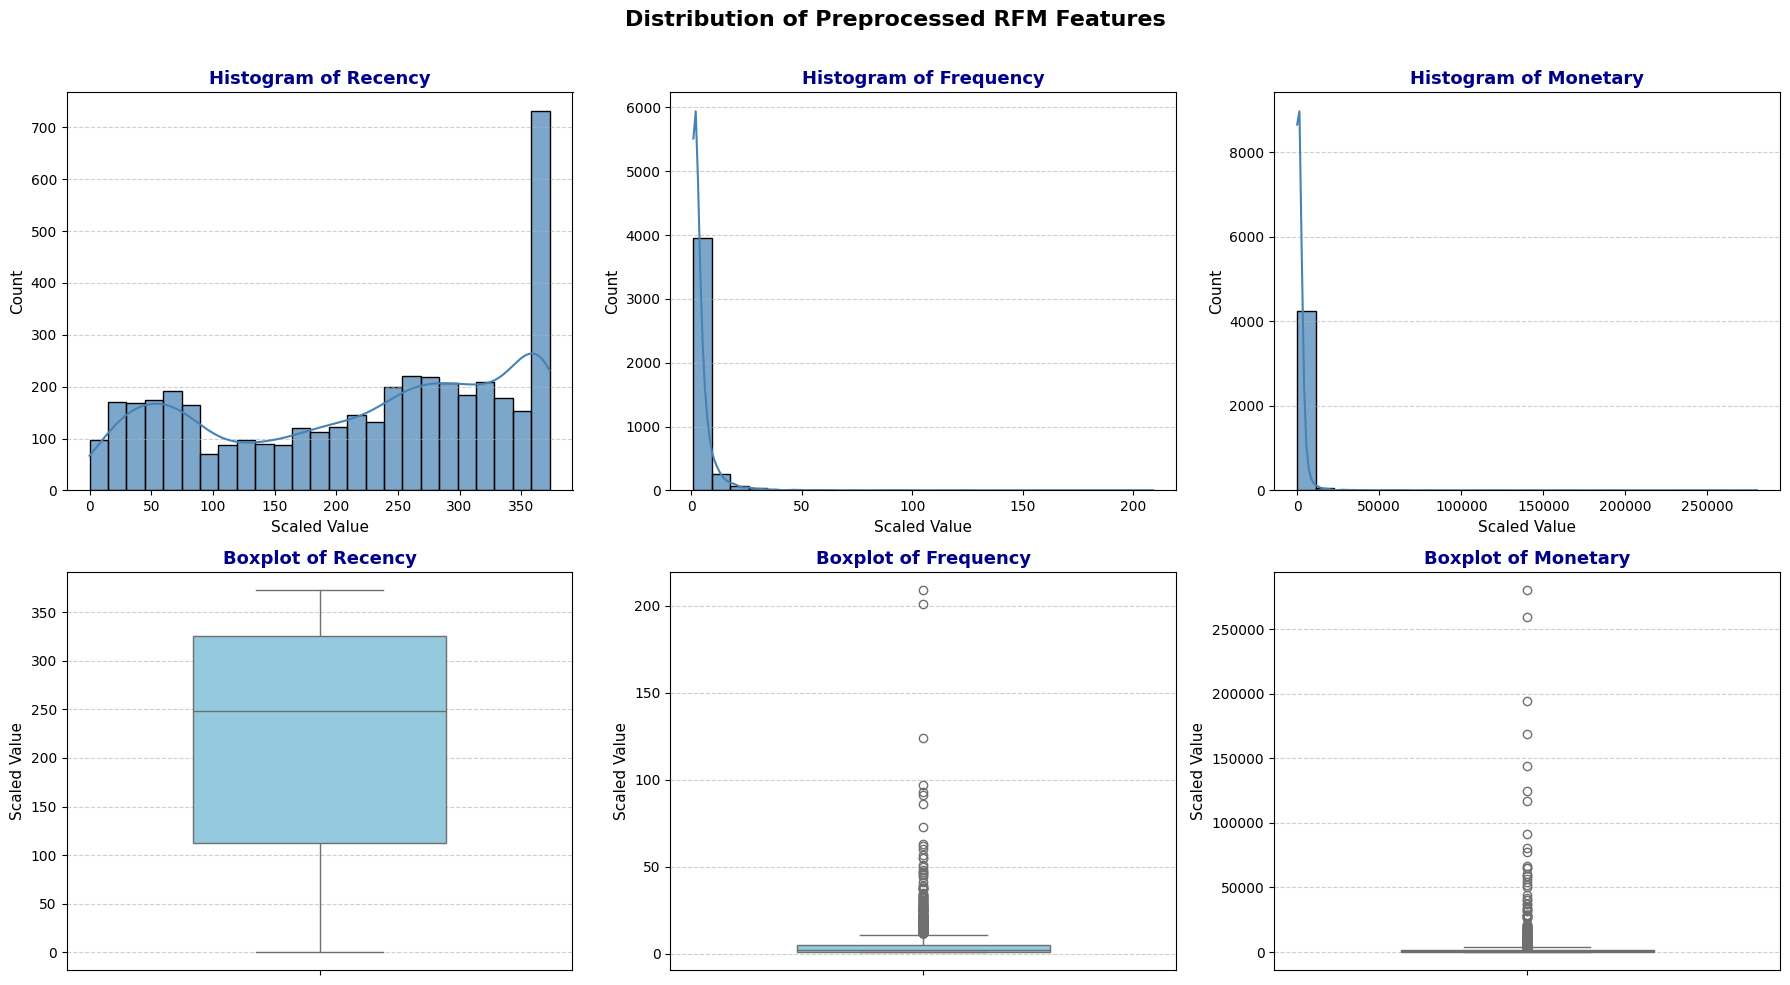

In [40]:
columns = ['Recency', 'Frequency', 'Monetary']

# --- Combined Histograms + Boxplots ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # 2 rows, 3 columns

for i, col in enumerate(agg_df.columns):
    # --- Histogram (row 1) ---
    sns.histplot(agg_df[col], bins=25, kde=True, ax=axes[0, i],
                 color='steelblue', alpha=0.7)
    axes[0, i].set_title(f"Histogram of {col}", fontsize=13, fontweight='bold', color='darkblue')
    axes[0, i].set_xlabel("Scaled Value", fontsize=11)
    axes[0, i].set_ylabel("Count", fontsize=11)
    axes[0, i].grid(axis='y', linestyle='--', alpha=0.6)

    # --- Boxplot (row 2) ---
    sns.boxplot(y=agg_df[col], ax=axes[1, i], color='skyblue', width=0.5)
    axes[1, i].set_title(f"Boxplot of {col}", fontsize=13, fontweight='bold', color='darkblue')
    axes[1, i].set_xlabel("")
    axes[1, i].set_ylabel("Scaled Value", fontsize=11)
    axes[1, i].grid(axis='y', linestyle='--', alpha=0.6)

# Improve spacing
plt.suptitle("Distribution of Preprocessed RFM Features", fontsize=16, fontweight='bold', color='black')
plt.tight_layout(rect=[0, 0, 1, 0.97])  # leave space for the suptitle
plt.show()


In [41]:
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, lower_pct=0.01, upper_pct=0.99):
        self.lower_pct = lower_pct
        self.upper_pct = upper_pct
        self.lower_bounds_ = None
        self.upper_bounds_ = None

    def fit(self, X, y=None):
        # Store bounds for each column
        self.lower_bounds_ = X.quantile(self.lower_pct)
        self.upper_bounds_ = X.quantile(self.upper_pct)
        return self

    def transform(self, X):
        X_capped = X.copy()
        for col in X.columns:
            X_capped[col] = X_capped[col].clip(
                lower=self.lower_bounds_[col],
                upper=self.upper_bounds_[col]
            )
        return X_capped

In [42]:
preprocess_pipeline = Pipeline([
    ("cap_outliers", OutlierCapper(lower_pct=0.00, upper_pct=0.80)),
    ("transform", PowerTransformer(method="yeo-johnson")),
    ("scale", StandardScaler())
])

# Apply preprocessing
rfm_cols = ['Recency', 'Frequency', 'Monetary']
scaled_rfm = preprocess_pipeline.fit_transform(agg_df[rfm_cols])

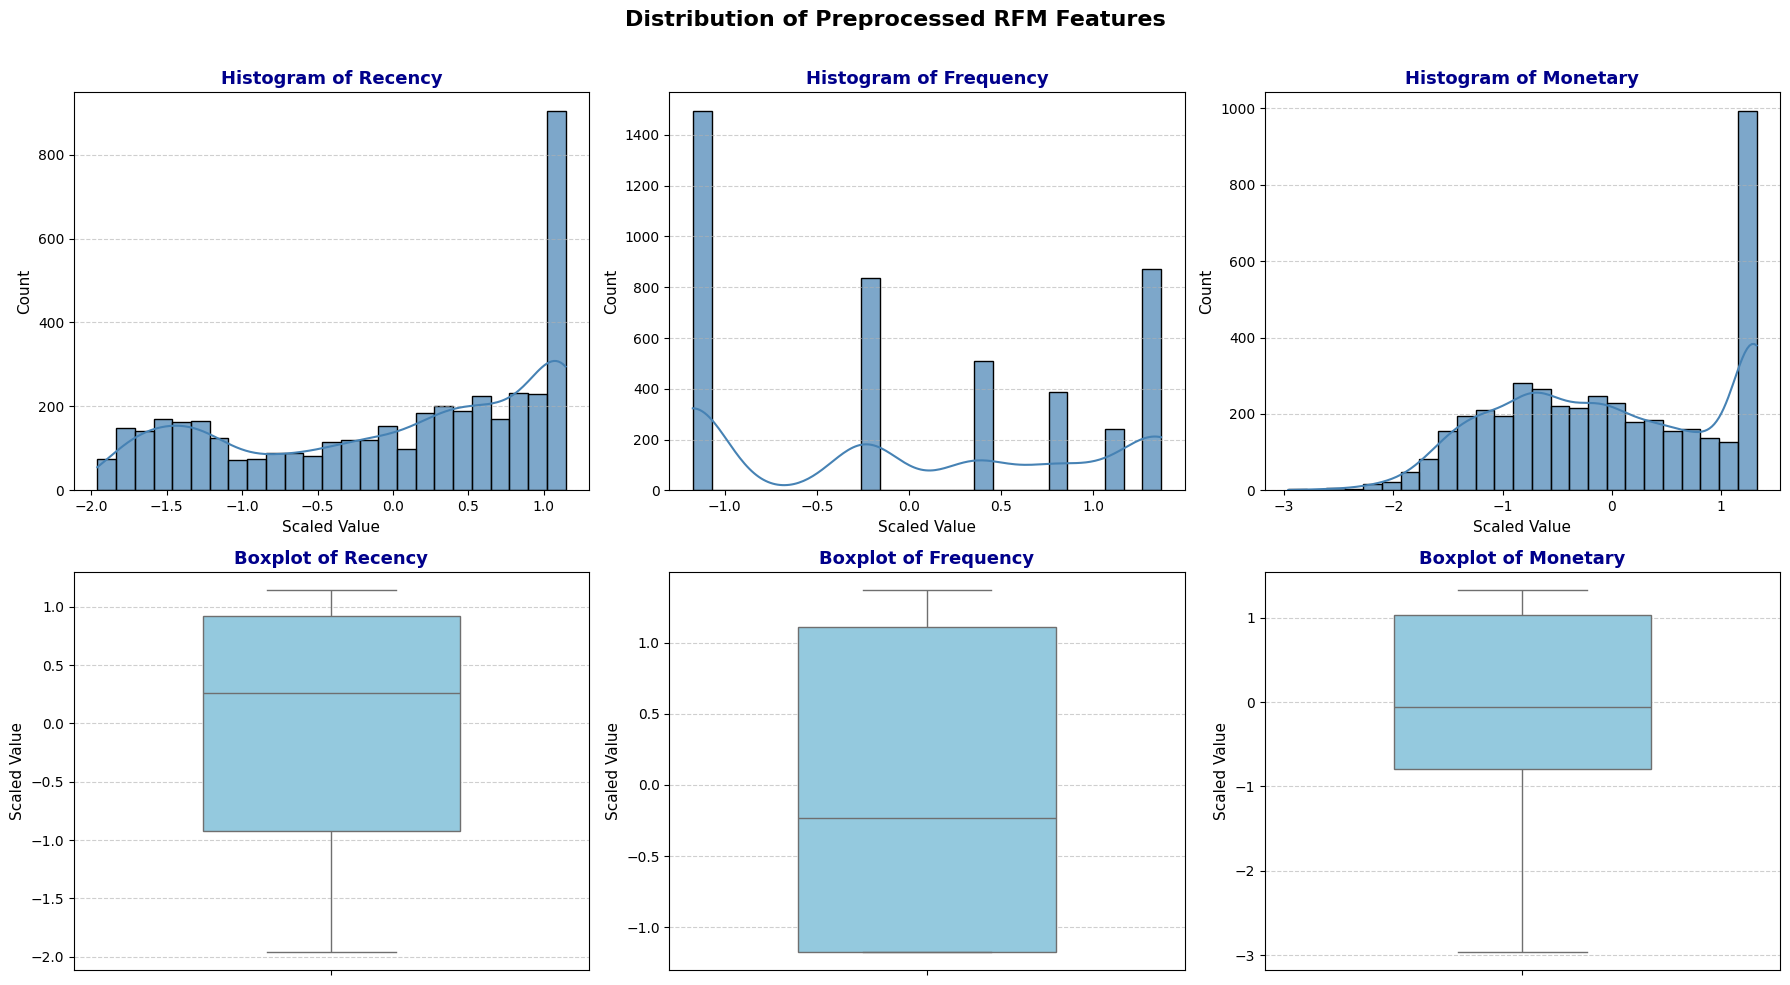

In [43]:
# Convert scaled_rfm back into a DataFrame with column names
scaled_rfm_df = pd.DataFrame(scaled_rfm, columns=rfm_cols)

# --- Combined Histograms + Boxplots ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # 2 rows, 3 columns

for i, col in enumerate(scaled_rfm_df.columns):
    # --- Histogram (row 1) ---
    sns.histplot(scaled_rfm_df[col], bins=25, kde=True, ax=axes[0, i],
                 color='steelblue', alpha=0.7)
    axes[0, i].set_title(f"Histogram of {col}", fontsize=13, fontweight='bold', color='darkblue')
    axes[0, i].set_xlabel("Scaled Value", fontsize=11)
    axes[0, i].set_ylabel("Count", fontsize=11)
    axes[0, i].grid(axis='y', linestyle='--', alpha=0.6)

    # --- Boxplot (row 2) ---
    sns.boxplot(y=scaled_rfm_df[col], ax=axes[1, i], color='skyblue', width=0.5)
    axes[1, i].set_title(f"Boxplot of {col}", fontsize=13, fontweight='bold', color='darkblue')
    axes[1, i].set_xlabel("")
    axes[1, i].set_ylabel("Scaled Value", fontsize=11)
    axes[1, i].grid(axis='y', linestyle='--', alpha=0.6)

# Improve spacing
plt.suptitle("Distribution of Preprocessed RFM Features", fontsize=16, fontweight='bold', color='black')
plt.tight_layout(rect=[0, 0, 1, 0.97])  # leave space for the suptitle
plt.show()


#### K-Means Clustering

##### Inertia and Silhoutte Score

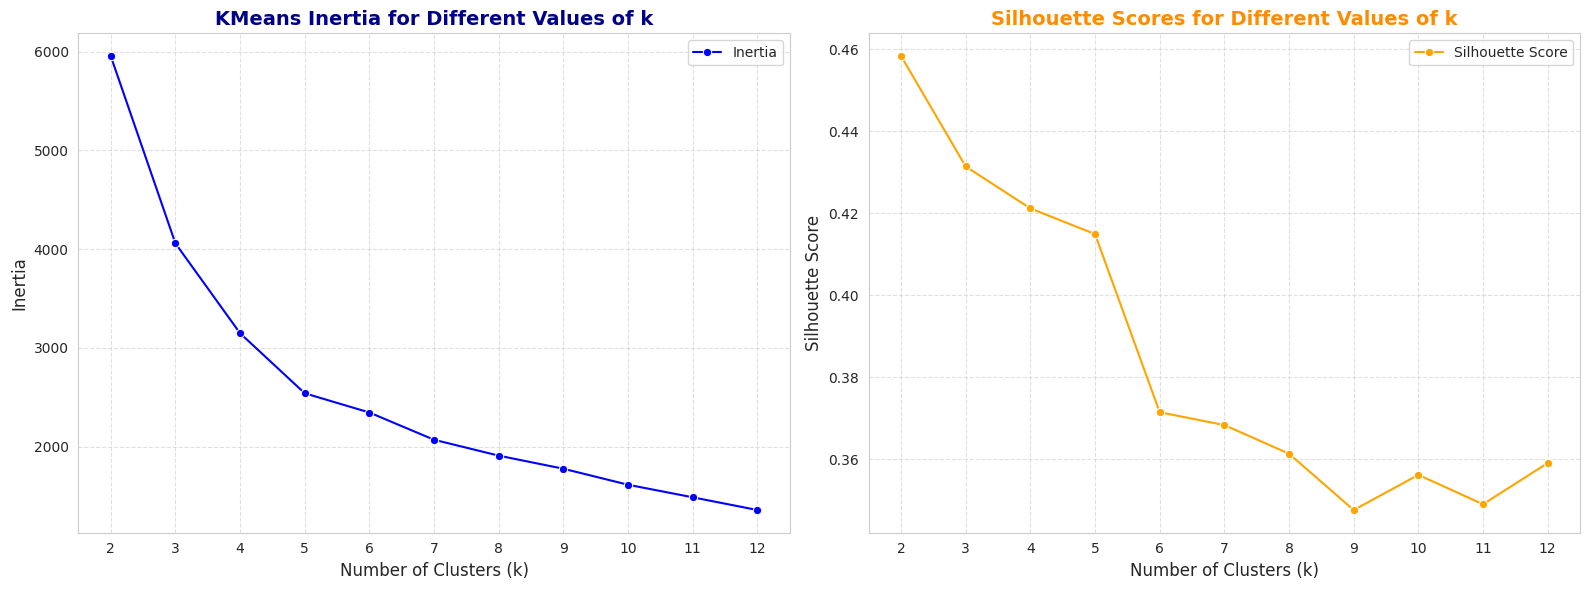

In [44]:
# --- KMeans evaluation ---
max_k = 12
inertia = []
silhouette_scores = []
k_values = range(2, max_k + 1)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000)
    cluster_labels = kmeans.fit_predict(scaled_rfm)

    sil_score = silhouette_score(scaled_rfm, cluster_labels)
    silhouette_scores.append(sil_score)
    inertia.append(kmeans.inertia_)

# --- Plot results ---
sns.set_style("whitegrid")
sns.set_palette("muted")

plt.figure(figsize=(16, 6))

# Inertia plot
plt.subplot(1, 2, 1)
sns.lineplot(x=k_values, y=inertia, marker='o', color='blue', label='Inertia')
plt.title('KMeans Inertia for Different Values of k', fontsize=14, fontweight='bold', color='darkblue')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.xticks(k_values, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)

# Silhouette plot
plt.subplot(1, 2, 2)
sns.lineplot(x=k_values, y=silhouette_scores, marker='o', color='orange', label='Silhouette Score')
plt.title('Silhouette Scores for Different Values of k', fontsize=14, fontweight='bold', color='darkorange')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(k_values, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [45]:
n_clusters = 4

# Fit KMeans with the chosen number of clusters
kmeans_final = KMeans(n_clusters=n_clusters, random_state=42, max_iter=1000)
agg_df['Cluster'] = kmeans_final.fit_predict(scaled_rfm)

# Check cluster sizes
print(agg_df['Cluster'].value_counts())

Cluster
1    1456
0    1131
2    1004
3     747
Name: count, dtype: int64


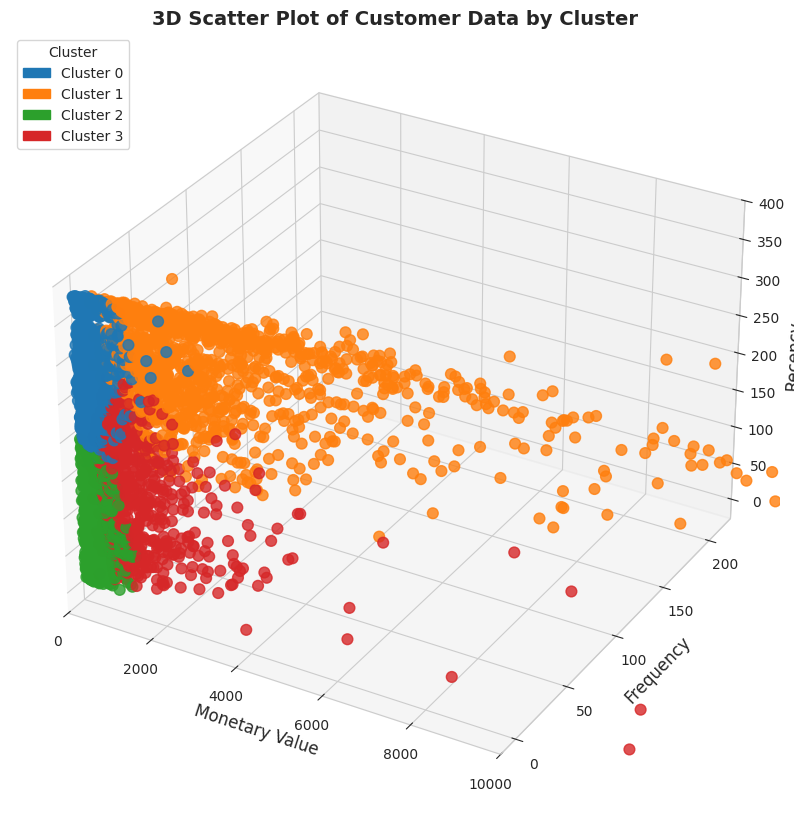

In [46]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches

# Define cluster colors
cluster_colors = {0: '#1f77b4',  # Blue
                  1: '#ff7f0e',  # Orange
                  2: '#2ca02c',  # Green
                  3: '#d62728',  # Red
                 }

# Map colors
colors = agg_df['Cluster'].map(cluster_colors)

# Create 3D scatter
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(agg_df['Monetary'],
                     agg_df['Frequency'],
                     agg_df['Recency'],
                     c=colors,
                     marker='o',
                     s=60,  # slightly larger points
                     alpha=0.8)

# Set axis labels
ax.set_xlabel('Monetary Value', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_zlabel('Recency', fontsize=12)

# Zoom in on Monetary
ax.set_xlim([0, 10000])

# Set title
ax.set_title('3D Scatter Plot of Customer Data by Cluster', fontsize=14, fontweight='bold')

# Create legend manually
patches = [mpatches.Patch(color=color, label=f'Cluster {cluster}') for cluster, color in cluster_colors.items()]
ax.legend(handles=patches, loc='upper left', title='Cluster')

plt.show()


In [47]:
agg_df.groupby(by = 'Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,286.865606,1.592396,441.056376
1,320.019918,9.105769,4693.559712
2,69.125498,1.157371,316.692819
3,139.445783,3.093708,1655.410442


##### Customer Segmentation Insights & Marketing Strategy Recommendations

Based on the RFM analysis of our customer base, we identified **four distinct segments** with unique purchasing behaviors. Understanding these segments allows us to implement **targeted marketing strategies**, optimize customer engagement, and maximize revenue.

---

**Customer Segment Summary**

| Cluster | Recency (days) | Frequency | Monetary (£) | Segment Insight |
|---------|----------------|----------|--------------|----------------|
| 0       | 287            | 1.6      | 441          | **Dormant / Low-Value Customers**: Inactive customers who purchase infrequently and generate low revenue. |
| 1       | 320            | 9.1      | 4,694        | **High-Value Loyal Customers**: Historically frequent purchasers contributing the highest revenue, but haven’t purchased recently. |
| 2       | 69             | 1.2      | 317          | **New / Recent Customers**: Recently acquired, low purchase frequency, and low monetary value. High potential for growth. |
| 3       | 139            | 3.1      | 1,655        | **Engaged Mid-Value Customers**: Moderate recency, frequency, and monetary value. Likely repeat buyers with potential to become high-value. |

**Interpretation:**  
- **Recency** highlights how long ago customers made a purchase. Lower values indicate more recent engagement.  
- **Frequency** reflects purchase regularity, critical for identifying loyal or repeat customers.  
- **Monetary** indicates revenue contribution, helping prioritize high-value customers.

---

**Marketing Strategy per Segment:**

**Cluster 0 – Dormant / Low-Value Customers:**  
This segment represents customers at risk of churn. They have low engagement and minimal contribution to revenue. Marketing efforts should focus on **reactivation and personalized engagement**, using win-back campaigns, limited-time incentives, and product recommendations to stimulate purchases. The goal is to increase purchase frequency and prevent churn.

**Cluster 1 – High-Value Loyal Customers:**  
These customers are our **top revenue contributors**. Although their recent purchase recency is high, they have demonstrated historical loyalty. Marketing strategies should focus on **retention and recognition**, including VIP programs, personalized thank-you campaigns, early access to new products, and advocacy initiatives. The objective is to maintain loyalty, maximize lifetime value, and convert them into brand advocates.

**Cluster 2 – New / Recent Customers:**  
This segment comprises **recently acquired customers** with low purchase frequency and monetary value. Early engagement is critical to drive repeat purchases. Recommended strategies include onboarding campaigns, second-purchase incentives, and enrollment in loyalty programs. The goal is to accelerate their transition into repeat, mid-value, or high-value customers.

**Cluster 3 – Engaged Mid-Value Customers:**  
These customers demonstrate moderate engagement and contribute meaningful revenue. Marketing strategies should focus on **upselling and cross-selling**, personalized promotions, bundle offers, and re-engagement reminders. The objective is to increase average order value and purchase frequency, moving them toward the high-value segment.

---

**Strategic Summary**

- **Segmentation enables targeted campaigns:** Allocate marketing resources efficiently based on customer behavior.  
- **Revenue growth potential:** Clusters 2 and 3 are opportunity segments for conversion and upselling.  
- **Retention focus:** Cluster 1 requires relationship nurturing to prevent revenue loss.  
- **Customer reactivation:** Cluster 0 offers a measurable win-back opportunity.  

**Overall:** Aligning marketing campaigns with these segments maximizes engagement, revenue, and customer lifetime value, while providing a personalized experience that strengthens brand loyalty.


### MBA: Market Basket Analysis

In [48]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [49]:
# Create basket: rows = InvoiceNo, columns = product description
basket = df.pivot_table(index='InvoiceNo',
                        columns='Description',
                        values='Quantity',
                        aggfunc='sum').fillna(0)

# Convert quantities to 1/0 (presence/absence)
basket_encoded = basket.applymap(lambda x: 1 if x > 0 else 0)

In [50]:
basket_encoded

Description   4 PURPLE FLOCK DINNER CANDLES   50'S CHRISTMAS GIFT BAG LARGE  \
InvoiceNo                                                                     
536365                                    0                               0   
536366                                    0                               0   
536367                                    0                               0   
536368                                    0                               0   
536369                                    0                               0   
...                                     ...                             ...   
581583                                    0                               0   
581584                                    0                               0   
581585                                    0                               0   
581586                                    0                               0   
581587                                    0                               0   

Description   DOLLY GIRL BEAKER   I LOVE LONDON MINI BACKPACK  \
InvoiceNo                                                       
536365                        0                             0   
536366                        0                             0   
536367                        0                             0   
536368                        0                             0   
536369                        0                             0   
...                         ...                           ...   
581583                        0                             0   
581584                        0                             0   
581585                        0                             0   
581586                        0                             0   
581587                        0                             0   

Description   I LOVE LONDON MINI RUCKSACK   NINE DRAWER OFFICE TIDY  \
InvoiceNo                                                             
536365                                  0                         0   
536366                                  0                         0   
536367                                  0                         0   
536368                                  0                         0   
536369                                  0                         0   
...                                   ...                       ...   
581583                                  0                         0   
581584                                  0                         0   
581585                                  0                         0   
581586                                  0                         0   
581587                                  0                         0   

Description   OVAL WALL MIRROR DIAMANTE    RED SPOT GIFT BAG LARGE  \
InvoiceNo                                                            
536365                                 0                         0   
536366                                 0                         0   
536367                                 0                         0   
536368                                 0                         0   
536369                                 0                         0   
...                                  ...                       ...   
581583                                 0                         0   
581584                                 0                         0   
581585                                 0                         0   
581586                                 0                         0   
581587                                 0                         0   

Description   SET 2 TEA TOWELS I LOVE LONDON    SPACEBOY BABY GIFT SET  \
InvoiceNo                                                                
536365                                      0                        0   
536366                                      0                        

In [51]:
from mlxtend.frequent_patterns import apriori

# Minimum support = 5% (product combinations appear in at least 5% of transactions)
frequent_itemsets = apriori(basket_encoded, min_support=0.05, use_colnames=True)

# Sort by support to see the most common sets
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)
frequent_itemsets.head(10)

/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: Dep

,support,itemsets
16,0.106357,(WHITE HANGING HEART T-LIGHT HOLDER)
13,0.091895,(REGENCY CAKESTAND 3 TIER)
2,0.086337,(JUMBO BAG RED RETROSPOT)
11,0.074412,(PARTY BUNTING)
0,0.074196,(ASSORTED COLOUR BIRD ORNAMENT)
6,0.069501,(LUNCH BAG RED RETROSPOT)
14,0.061839,(SET OF 3 CAKE TINS PANTRY DESIGN )
12,0.059303,(POSTAGE)
3,0.056767,(LUNCH BAG BLACK SKULL.)
9,0.055526,(PACK OF 72 RETROSPOT CAKE CASES)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [52]:
from mlxtend.frequent_patterns import association_rules

# Generate rules with minimum lift of 1.2
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

# Sort by lift to find strongest rules
rules = rules.sort_values(by='lift', ascending=False)

# Show top 10 rules
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

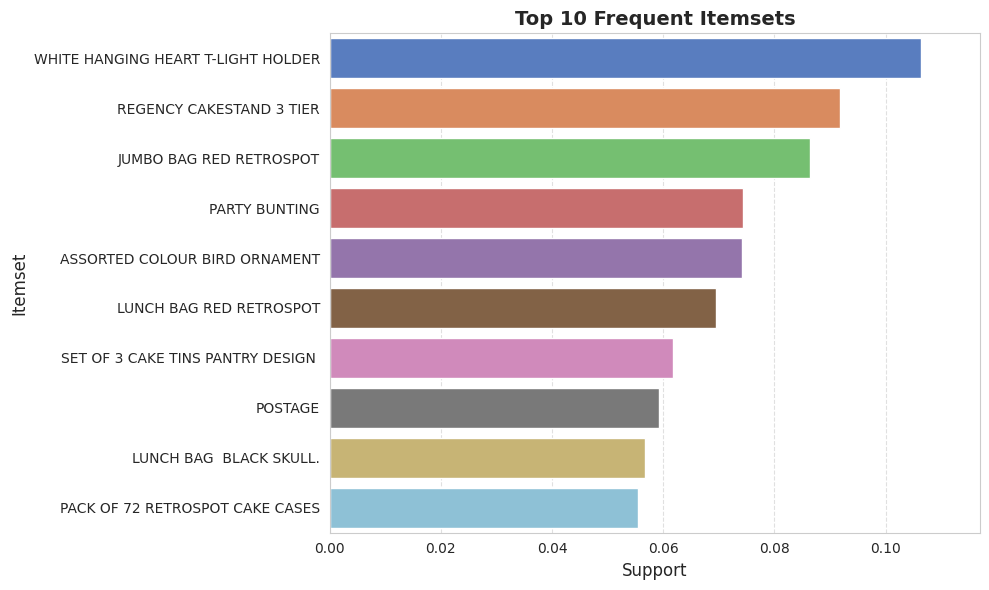

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [53]:
# Take top 10 frequent itemsets by support
top_itemsets = frequent_itemsets.sort_values(by='support', ascending=False).head(10)

# Convert frozensets to strings for plotting
top_itemsets['itemset_str'] = top_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='support', y='itemset_str', data=top_itemsets, palette='muted')
plt.xlabel('Support', fontsize=12)
plt.ylabel('Itemset', fontsize=12)
plt.title('Top 10 Frequent Itemsets', fontsize=14, fontweight='bold')
plt.xlim(0, top_itemsets['support'].max()*1.1)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### BG/NBD Model

https://lifetimes.readthedocs.io/en/latest/Quickstart.html#basic-frequency-recency-analysis-using-the-bg-nbd-model

In [54]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [55]:
# End of observation period
end_date = df['InvoiceDate'].max()


In [56]:
# Group by customer
customer_summary = df.groupby('CustomerID').agg(
    first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max'),
    total_purchases=('InvoiceNo', 'nunique'),
    total_spent=('TotalPrice', 'sum')
).reset_index()

# Frequency: number of repeat purchase occasions (days with purchases - 1)
purchase_days = df.groupby(['CustomerID', df['InvoiceDate'].dt.date])['InvoiceNo'].nunique().reset_index()
purchase_days = purchase_days.groupby('CustomerID').size().reset_index(name='purchase_days')

customer_summary = customer_summary.merge(purchase_days, on='CustomerID', how='left')
customer_summary['frequency'] = customer_summary['purchase_days'] - 1
customer_summary['frequency'] = customer_summary['frequency'].clip(lower=0)

# Recency: time between first and last purchase (in weeks)
customer_summary['recency'] = (customer_summary['last_purchase'] - customer_summary['first_purchase']).dt.days / 7

# T: customer age = time between first purchase and end of study (in weeks)
customer_summary['T'] = (end_date - customer_summary['first_purchase']).dt.days / 7

# Monetary value: average spend per transaction
customer_summary['monetary_value'] = customer_summary['total_spent'] / customer_summary['total_purchases']


In [57]:
rfm = customer_summary[['CustomerID', 'frequency', 'recency', 'T', 'monetary_value']]
print(rfm.head())


   CustomerID  frequency    recency          T  monetary_value
0     12346.0          0   0.000000  46.428571    77183.600000
1     12347.0          6  52.142857  52.285714      615.714286
2     12348.0          3  40.285714  51.000000      449.310000
3     12349.0          0   0.000000   2.571429     1757.550000
4     12350.0          0   0.000000  44.142857      334.400000


In [58]:
bgf = BetaGeoFitter(penalizer_coef=1e-06)
bgf.fit(rfm['frequency'], rfm['recency'], rfm['T'])


<lifetimes.BetaGeoFitter: fitted with 4338 subjects, a: 0.00, alpha: 9.81, b: 3.04, r: 0.83>

In [59]:
bgf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
r,0.826966,0.026811,0.774417,0.879516
alpha,9.814291,0.373059,9.083094,10.545487
a,0.002231,0.006168,-0.009858,0.014320
b,3.037160,6.056129,-8.832854,14.907173


<Axes: title={'center': 'Expected Number of Future Purchases for 1 Unit of Time,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

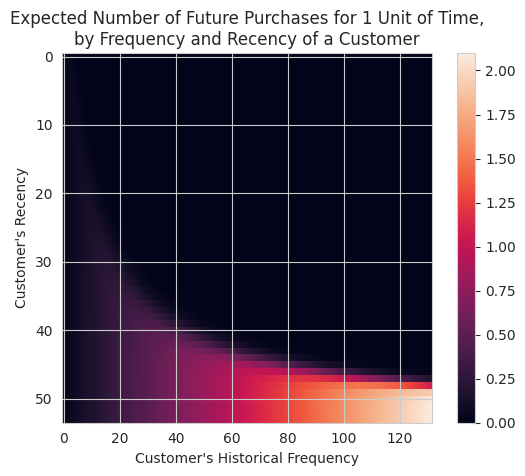

In [60]:
plot_frequency_recency_matrix(bgf)

<Axes: title={'center': 'Probability Customer is Alive,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

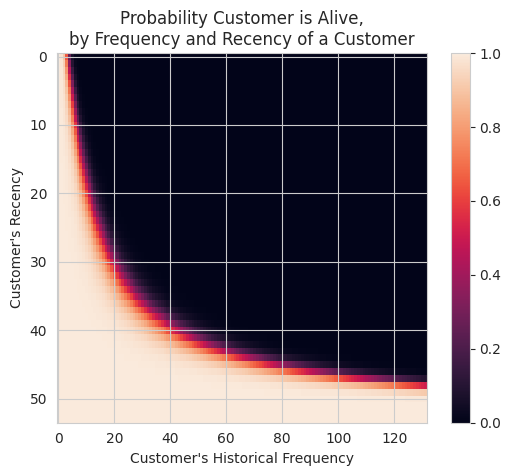

In [61]:
plot_probability_alive_matrix(bgf)

<Axes: title={'center': 'Frequency of Repeat Transactions'}, xlabel='Number of Calibration Period Transactions', ylabel='Customers'>

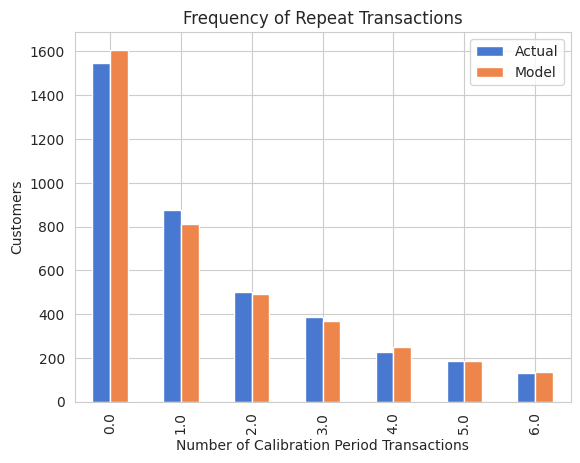

In [62]:
plot_period_transactions(bgf)

#### Train Test Split

In [63]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [64]:
# Define cutoff dates (weekly basis)
end_date = df['InvoiceDate'].max()
calibration_end = end_date - pd.Timedelta(weeks=12)

summary_cal_holdout = calibration_and_holdout_data(
    transactions = df,
    customer_id_col = 'CustomerID',
    datetime_col = 'InvoiceDate',
    monetary_value_col = 'TotalPrice',
    freq = 'W',  # Weekly aggregation
    calibration_period_end = calibration_end,
    observation_period_end = end_date
)

summary_cal_holdout.head()



,frequency_cal,recency_cal,T_cal,monetary_value_cal,frequency_holdout,monetary_value_holdout,duration_holdout
CustomerID,,,,,,,
12346.0,0.0,0.0,34.0,0.0000,0.0,0.000000,12.0
12347.0,4.0,34.0,40.0,519.7675,2.0,26.192069,12.0
12348.0,2.0,16.0,39.0,297.2200,1.0,103.333333,12.0
12350.0,0.0,0.0,32.0,0.0000,0.0,0.000000,12.0
12352.0,3.0,5.0,30.0,421.7700,3.0,20.090000,12.0


In [65]:
# 1. Drop customers with no repeat purchases in calibration
summary_cal_holdout = summary_cal_holdout[summary_cal_holdout['frequency_cal'] > 0]

# 2. Drop customers with non-positive monetary value
summary_cal_holdout = summary_cal_holdout[summary_cal_holdout['monetary_value_cal'] > 0]

# 3. (Optional) Cap extreme outliers in monetary value
summary_cal_holdout['monetary_value_cal'] = summary_cal_holdout['monetary_value_cal'].clip(
    upper=summary_cal_holdout['monetary_value_cal'].quantile(0.95)
)

# 4. Reset index
summary_cal_holdout = summary_cal_holdout.reset_index()

# 5. Check correlation assumption for Gamma-Gamma
from scipy.stats import pearsonr
corr, pval = pearsonr(summary_cal_holdout['frequency_cal'], summary_cal_holdout['monetary_value_cal'])
print(f"Correlation: {corr:.3f}, p-value: {pval:.3f}")


Correlation: 0.192, p-value: 0.000


#### Model Fitting

In [66]:
from lifetimes import BetaGeoFitter

# Initialize the model
bgf = BetaGeoFitter(penalizer_coef=1e-06)

# Fit the model on calibration data
bgf.fit(
    frequency=summary_cal_holdout['frequency_cal'],
    recency=summary_cal_holdout['recency_cal'],
    T=summary_cal_holdout['T_cal']
)

print(bgf.summary)


            coef  se(coef)  lower 95% bound  upper 95% bound
r       2.826723  0.151461         2.529860         3.123587
alpha  22.793688  1.267057        20.310257        25.277120
a       0.009703  0.008002        -0.005981         0.025387
b       0.091784  0.075805        -0.056794         0.240362


#### Model Evaluation

In [67]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Predict expected purchases in holdout period
summary_cal_holdout['predicted_purchases_holdout'] = bgf.predict(
    summary_cal_holdout['duration_holdout'],
    summary_cal_holdout['frequency_cal'],
    summary_cal_holdout['recency_cal'],
    summary_cal_holdout['T_cal']
)

# Evaluate
y_true = summary_cal_holdout['frequency_holdout']
y_pred = summary_cal_holdout['predicted_purchases_holdout']

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print(f"RMSE: {rmse:.3f}, MAE: {mae:.3f}")


RMSE: 1.420, MAE: 1.026


<Axes: title={'center': 'Expected Number of Future Purchases for 1 Unit of Time,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

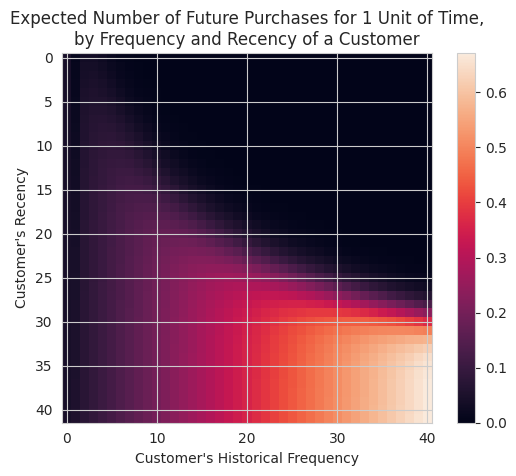

In [68]:
plot_frequency_recency_matrix(bgf)

<Axes: title={'center': 'Actual Purchases in Holdout Period vs Predicted Purchases'}, xlabel='Purchases in calibration period', ylabel='Average of Purchases in Holdout Period'>

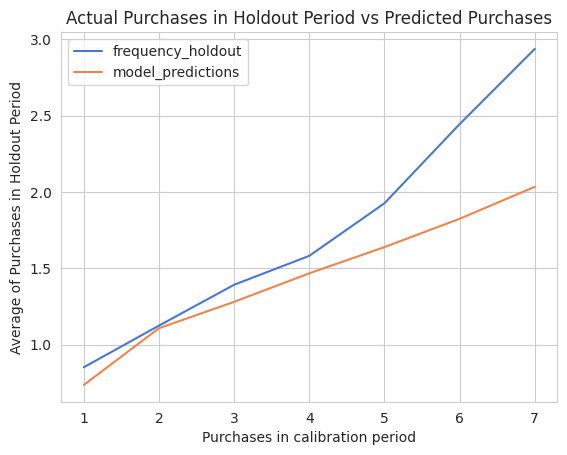

In [69]:
from lifetimes.plotting import plot_calibration_purchases_vs_holdout_purchases

plot_calibration_purchases_vs_holdout_purchases(bgf, summary_cal_holdout)


Validation using usual Machine Learning metrics. Note that the following metrics below were computed on customers with at least one repeat purchase in calibration, since BG/NBD requires frequency > 0 for stable predictions.

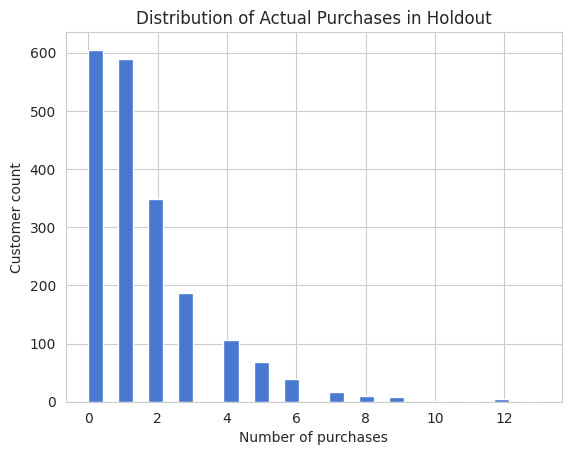

In [70]:
plt.hist(summary_cal_holdout['frequency_holdout'], bins=30)
plt.title("Distribution of Actual Purchases in Holdout")
plt.xlabel("Number of purchases")
plt.ylabel("Customer count")
plt.show()


#### Predict Future Purchases given time T

In [71]:
def predict_future_purchases(bgf, summary_data, horizons=[4, 8, 12, 24]):
    results = summary_data[['CustomerID']].copy()
    for t in horizons:
        results[f'pred_{t}_weeks'] = bgf.predict(
            t,
            summary_data['frequency_cal'],
            summary_data['recency_cal'],
            summary_data['T_cal']
        )
    return results

pred_table = predict_future_purchases(bgf, summary_cal_holdout)
pred_table.head()


,CustomerID,pred_4_weeks,pred_8_weeks,pred_12_weeks,pred_24_weeks
0,12347.0,0.431929,0.863398,1.294452,2.585445
1,12348.0,0.287971,0.575503,0.862647,1.722136
2,12352.0,0.369161,0.737800,1.105979,2.208194
3,12356.0,0.151988,0.303596,0.454883,0.907224
4,12359.0,0.321581,0.642643,0.963249,1.922803


#### Probability of a Customer being Alive

**Interpretation:** Higher probability_alive means the model believes the customer is still active. Typically, customers with recent purchases and higher frequency have higher probabilities.

In [72]:
summary_cal_holdout['probability_alive'] = bgf.conditional_probability_alive(
    summary_cal_holdout['frequency_cal'],
    summary_cal_holdout['recency_cal'],
    summary_cal_holdout['T_cal']
)

In [73]:
# Inspect top customers most likely to be alive
summary_cal_holdout[['CustomerID', 'frequency_cal', 'recency_cal', 'T_cal', 'probability_alive']] \
    .sort_values('probability_alive', ascending=False) \
    .head(10)


,CustomerID,frequency_cal,recency_cal,T_cal,probability_alive
765,14606.0,40.0,41.0,41.0,0.999752
1845,17841.0,39.0,41.0,41.0,0.999745
743,14527.0,37.0,41.0,41.0,0.999731
1007,15311.0,36.0,41.0,41.0,0.999724
219,12971.0,35.0,41.0,41.0,0.999715
874,14911.0,35.0,41.0,41.0,0.999715
151,12748.0,34.0,41.0,41.0,0.999707
1357,16422.0,32.0,41.0,41.0,0.999688
485,13798.0,29.0,41.0,41.0,0.999655
1660,17315.0,24.0,39.0,39.0,0.999580


In [74]:
# Inspect customers unlikely to be alive
summary_cal_holdout[['CustomerID', 'frequency_cal', 'recency_cal', 'T_cal', 'probability_alive']] \
    .sort_values('probability_alive', ascending=True) \
    .head(10)

,CustomerID,frequency_cal,recency_cal,T_cal,probability_alive
1624,17198.0,1.0,1.0,41.0,0.178425
1010,15332.0,1.0,1.0,41.0,0.178425
976,15224.0,1.0,1.0,40.0,0.187461
1381,16499.0,1.0,1.0,40.0,0.187461
1791,17691.0,1.0,1.0,40.0,0.187461
809,14723.0,1.0,2.0,41.0,0.202698
218,12967.0,1.0,2.0,41.0,0.202698
1885,17951.0,1.0,2.0,41.0,0.202698
174,12829.0,1.0,3.0,39.0,0.250432
75,12559.0,1.0,1.0,33.0,0.266139


This heatmap shows probability_alive across combinations of frequency and recency (in your chosen time units). It’s a great diagnostic to see how the model behaves.

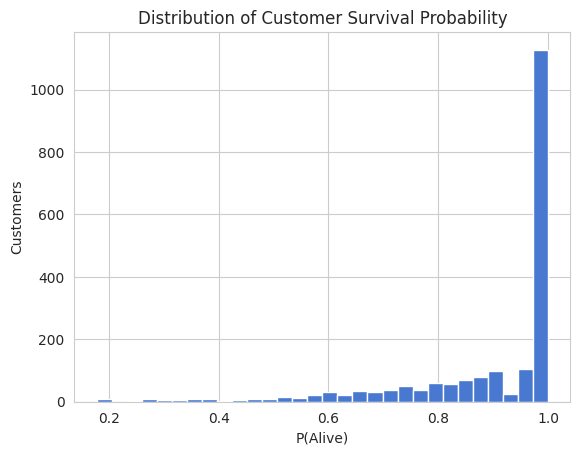

In [75]:
# Histogram of probabilities
summary_cal_holdout['probability_alive'].hist(bins=30)
plt.title("Distribution of Customer Survival Probability")
plt.xlabel("P(Alive)")
plt.ylabel("Customers")
plt.show()


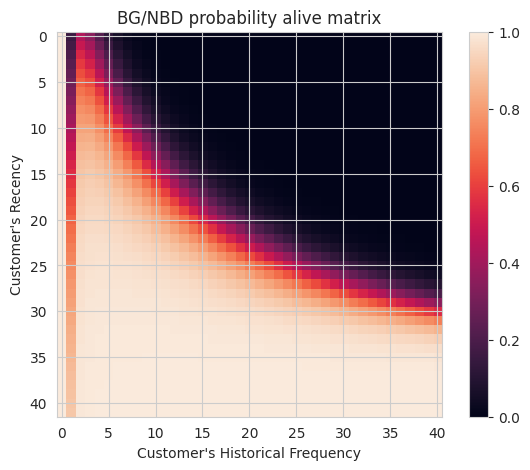

In [76]:
from lifetimes.plotting import plot_probability_alive_matrix

plt.figure(figsize=(7,5))
plot_probability_alive_matrix(bgf)
plt.title('BG/NBD probability alive matrix')
plt.show()


Probability of being alive for a Specific Customer

In [77]:
def plot_probability_alive_for_customer(bgf, summary_data, customer_id, horizon=12, step=1):
    """
    Plot probability alive over time for a given customer_id.

    Parameters
    ----------
    bgf : lifetimes.BetaGeoFitter
        A fitted BG/NBD model.
    summary_data : pd.DataFrame
        Calibration/holdout summary with columns ['CustomerID','frequency_cal','recency_cal','T_cal'].
    customer_id : int or str
        The customer ID to plot.
    horizon : int
        How far into the future to project (in same units as calibration, e.g. weeks).
    step : int
        Step size for the time grid.
    """
    # Ensure CustomerID is a column
    if 'CustomerID' not in summary_data.columns:
        summary_data = summary_data.reset_index()

    # Get this customer's calibration values
    row = summary_data.loc[summary_data['CustomerID'] == customer_id].iloc[0]

    # Build time grid
    times = np.arange(row['T_cal'], row['T_cal'] + horizon + step, step)

    # Compute probability alive
    probs = bgf.conditional_probability_alive(
        row['frequency_cal'],
        row['recency_cal'],
        times
    )

    # Plot
    plt.figure(figsize=(7,4))
    plt.plot(times, probs, marker='o')
    plt.xlabel('Time (same units as calibration)')
    plt.ylabel('Probability Alive')
    plt.title(f"Customer {customer_id} - Probability Alive Over Time")
    plt.grid(True, alpha=0.3)
    plt.show()


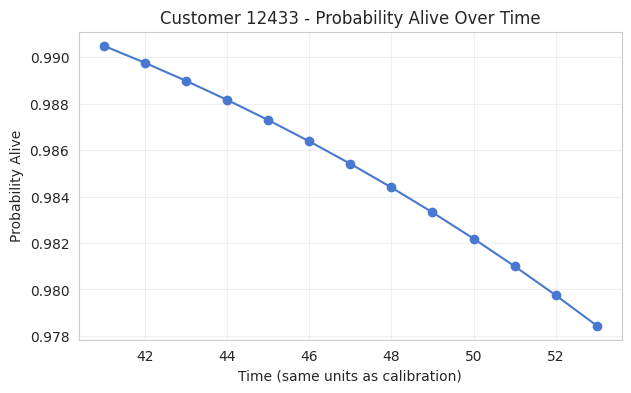

In [78]:
# Example: plot for customer 12433
plot_probability_alive_for_customer(bgf, summary_cal_holdout, customer_id=12433, horizon=12, step=1)


In [79]:
def plot_top_bottom_probability_alive(bgf, summary_data, top_n=5, horizon=12, step=1):
    """
    Plot probability alive curves for the top and bottom N customers
    ranked by probability_alive.
    """
    # Ensure CustomerID is a column
    if 'CustomerID' not in summary_data.columns:
        summary_data = summary_data.reset_index()

    # Sort customers by probability_alive
    top_customers = summary_data.sort_values('probability_alive', ascending=False).head(top_n)
    bottom_customers = summary_data.sort_values('probability_alive', ascending=True).head(top_n)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    # Plot top customers
    for _, row in top_customers.iterrows():
        times = np.arange(row['T_cal'], row['T_cal'] + horizon + step, step)
        probs = bgf.conditional_probability_alive(
            row['frequency_cal'], row['recency_cal'], times
        )
        axes[0].plot(times, probs, label=f"Cust {int(row['CustomerID'])}")
    axes[0].set_title(f"Top {top_n} Customers (Highest probability_alive)")
    axes[0].set_xlabel("Time (same units as calibration)")
    axes[0].set_ylabel("Probability Alive")
    axes[0].legend()

    # Plot bottom customers
    for _, row in bottom_customers.iterrows():
        times = np.arange(row['T_cal'], row['T_cal'] + horizon + step, step)
        probs = bgf.conditional_probability_alive(
            row['frequency_cal'], row['recency_cal'], times
        )
        axes[1].plot(times, probs, label=f"Cust {int(row['CustomerID'])}")
    axes[1].set_title(f"Bottom {top_n} Customers (Lowest probability_alive)")
    axes[1].set_xlabel("Time (same units as calibration)")
    axes[1].legend()

    plt.suptitle("BG/NBD Probability Alive Curves", fontsize=14)
    plt.tight_layout()
    plt.show()


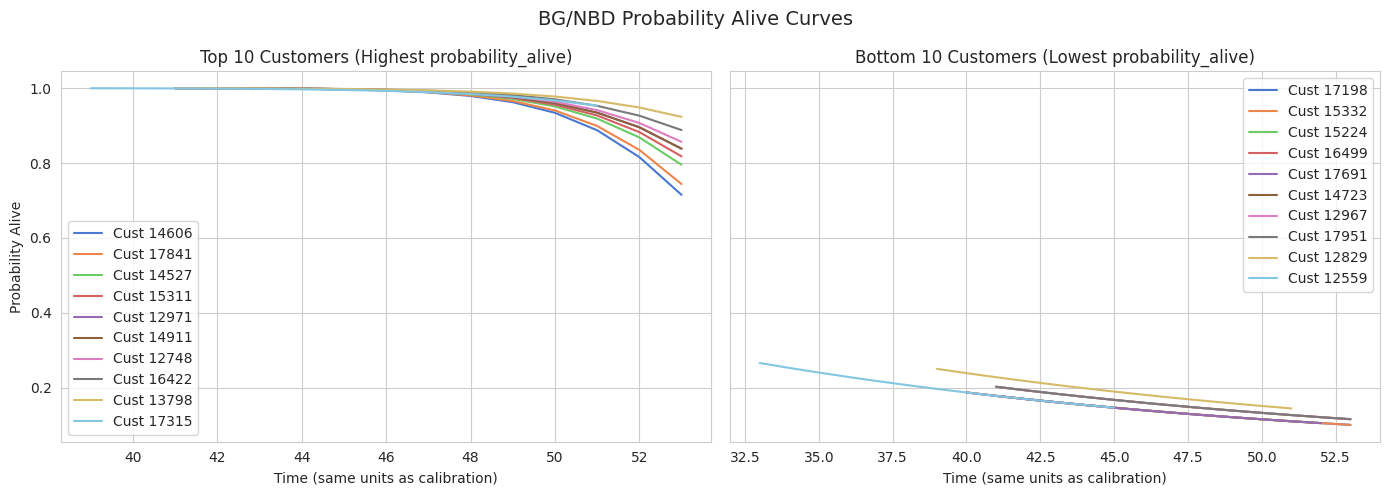

In [80]:
plot_top_bottom_probability_alive(bgf, summary_cal_holdout, top_n=10, horizon=12, step=1)


### Customer Lifetime Value

#### Gamma-Gamma Model

##### Model Fitting

In [81]:
from scipy.stats import pearsonr

# Filter calibration data
gg_data = summary_cal_holdout[
    (summary_cal_holdout['frequency_cal'] > 0) &
    (summary_cal_holdout['monetary_value_cal'] > 0)
]

# Compute Pearson correlation
corr, pval = pearsonr(summary_cal_holdout['frequency_cal'], summary_cal_holdout['monetary_value_cal'])

print(f"Pearson correlation: {corr:.3f}, p-value: {pval:.3f}")


Pearson correlation: 0.192, p-value: 0.000


In [82]:
from lifetimes import GammaGammaFitter

ggf = GammaGammaFitter(penalizer_coef=1e-6)
ggf.fit(
    gg_data['frequency_cal'],
    gg_data['monetary_value_cal']
)


<lifetimes.GammaGammaFitter: fitted with 1987 subjects, p: 4.52, q: 2.77, v: 160.73>

**ggf.summary**

- The model suggests that customers spend, on average, ~365 per transaction, with moderate variation across the population.
- The p and q values around 2–3 suggest moderate variation — customers differ in spend, but not wildly.
- Because the correlation assumption check (Pearson’s r) was close to zero, it’s valid to combine this Gamma-Gamma model with your BG/NBD purchase frequency model.
- Together, we can estimate Customer Lifetime Value (CLV) by the following:

```
CLV:
Expected Transactions (BG/NBD) × Expected Spend per Transaction (Gamma-Gamma)
```

In [83]:
ggf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
p,4.519290,0.223401,4.081425,4.957156
q,2.771981,0.097366,2.581145,2.962818
v,160.731371,10.023689,141.084941,180.377802


In [84]:
gg_data['expected_avg_value'] = ggf.conditional_expected_average_profit(
    gg_data['frequency_cal'],
    gg_data['monetary_value_cal']
)


In [85]:
weeks = 12  # horizon
discount_rate = 0.00  # weekly discount rate

gg_data['predicted_clv'] = ggf.customer_lifetime_value(
    bgf,
    gg_data['frequency_cal'],
    gg_data['recency_cal'],
    gg_data['T_cal'],
    gg_data['monetary_value_cal'],
    time=weeks,             # number of weeks into future
    discount_rate=discount_rate,  # weekly discount rate
    freq='W'
)

##### Model Evaluation

In [86]:
# Actual holdout spending
y_true_value = gg_data['monetary_value_holdout']

# Predicted spending (approximation: avg value * predicted purchases)
y_pred_value = gg_data['expected_avg_value'] * gg_data['predicted_purchases_holdout']

# Drop NaNs if any
mask = (~y_true_value.isna()) & (~y_pred_value.isna())
y_true_value = y_true_value[mask]
y_pred_value = y_pred_value[mask]

# Evaluation metrics
mae_value = mean_absolute_error(y_true_value, y_pred_value)
rmse_value = np.sqrt(mean_squared_error(y_true_value, y_pred_value))
r2_value = r2_score(y_true_value, y_pred_value)

print(f"Gamma–Gamma Evaluation on Holdout:")
print(f"  MAE : {mae_value:.2f}")
print(f"  RMSE: {rmse_value:.2f}")
print(f"  R²  : {r2_value:.3f}")


Gamma–Gamma Evaluation on Holdout:
  MAE : 516.44
  RMSE: 796.08
  R²  : -97.837


#### Hybrid CLV: (BG/NBD + ML)

In [87]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [88]:
# 1. Feature Selection
X = gg_data.copy()  # make a working copy so we don’t overwrite gg_data
X['avg_monetary_value'] = X['monetary_value_cal']
X['total_cal_value'] = X['monetary_value_cal'] * (X['frequency_cal'] + 1)
X['monetary_per_week'] = X['total_cal_value'] / X['T_cal'].replace(0, np.nan)

# Ratios and interactions
X['recency_ratio'] = X['recency_cal'] / X['T_cal'].replace(0, np.nan)
X['value_per_purchase'] = X['monetary_value_cal'] / (X['frequency_cal'] + 1)

# Past vs future ratio (if holdout exists)
if 'monetary_value_holdout' in X.columns:
    X['future_past_ratio'] = X['monetary_value_holdout'] / (X['monetary_value_cal'] + 1)

# Include probabilistic model outputs
X['predicted_purchases'] = gg_data['predicted_purchases_holdout']
X['expected_value'] = gg_data['expected_avg_value']

# Final feature set
feature_cols = [
    'frequency_cal', 'recency_cal', 'T_cal',
    'avg_monetary_value', 'total_cal_value', 'monetary_per_week',
    'recency_ratio', 'value_per_purchase', 'predicted_purchases', 'expected_value'
]

y = gg_data['monetary_value_holdout']
X = X[feature_cols]

In [89]:
# 2. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [90]:
# 3. Model Fitting and Parameter Tuning

params = {
    'n_estimators': [300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_lambda': [5.0, 10.0]
}

xgb = XGBRegressor(
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)

grid = GridSearchCV(
    xgb,
    param_grid=params,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("✅ Best Parameters:")
print(grid.best_params_)
best_xgb = grid.best_estimator_

Fitting 3 folds for each of 144 candidates, totalling 432 fits
✅ Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300, 'reg_lambda': 10.0, 'subsample': 1.0}


In [91]:
# 4. Model Evaluation
y_pred = best_xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊 XGBoost Hybrid Evaluation on Holdout:")
print(f"  MAE : {mae:.3f}")
print(f"  RMSE: {rmse:.3f}")
print(f"  R²  : {r2:.3f}")


📊 XGBoost Hybrid Evaluation on Holdout:
  MAE : 18.455
  RMSE: 34.363
  R²  : -0.126


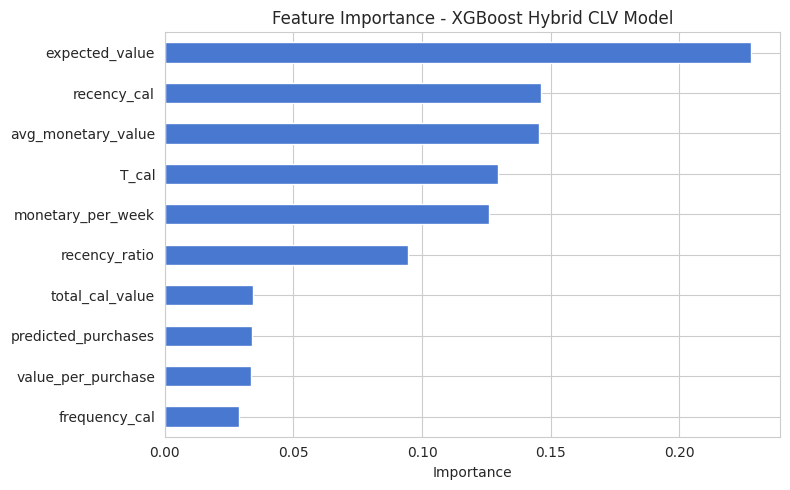

In [92]:
# 5. Feature Importance
importance = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(8,5))
importance.plot(kind='barh')
plt.title("Feature Importance - XGBoost Hybrid CLV Model")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [119]:
gg_data.head()

,CustomerID,frequency_cal,recency_cal,T_cal,monetary_value_cal,frequency_holdout,monetary_value_holdout,duration_holdout,predicted_purchases_holdout,probability_alive,expected_avg_value,predicted_clv
0,12347.0,4.0,34.0,40.0,519.7675,2.0,26.192069,12.0,1.294452,0.993809,509.962216,2857.283650
1,12348.0,2.0,16.0,39.0,297.2200,1.0,103.333333,12.0,0.862647,0.922447,315.694849,1177.304051
2,12352.0,3.0,5.0,30.0,421.7700,3.0,20.090000,12.0,1.105979,0.836853,420.401640,2010.702140
3,12356.0,1.0,11.0,34.0,481.4600,1.0,29.175000,12.0,0.454883,0.564720,461.313626,905.074025
4,12359.0,2.0,20.0,35.0,1043.4305,1.0,27.591176,12.0,0.963249,0.963482,939.592471,3911.808591


### Customer Segmentation

##### Customer Segmentation Insights & Marketing Strategy Recommendations

Based on the behavioral and predictive features derived from our models—including BG/NBD for purchase frequency and probability alive, Gamma-Gamma for expected transaction value, and XGBoost hybrid predictions for total CLV—we performed feature engineering, outlier treatment, and transformations before applying K-Means clustering. PCA was used to visualize cluster separation and patterns.

We identified three distinct customer segments with unique purchasing behaviors. Understanding these segments allows us to implement targeted marketing strategies, optimize customer engagement, and maximize revenue.

---

**Customer Segment Summary**

| Cluster | Frequency (avg) | Recency (weeks) | Tenure (weeks) | Predicted CLV (£) | Segment Insight                                                                                                                                                                 |
| ------- | --------------- | --------------- | -------------- | ----------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 0       | 4.10            | 28.85           | 33.62          | 20.95             | **Mid-Value Customers**: Moderate frequency and tenure, contributing meaningful revenue. Likely repeat buyers with potential to increase value.                                 |
| 1       | 1.26            | 11.33           | 25.29          | 13.33             | **Low-Value Occasional Buyers**: Low frequency, shorter tenure, smaller revenue contribution. At risk of churn or inactivity.                                                   |
| 2       | 13.51           | 35.61           | 37.79          | 126.20            | **VIP Power Buyers**: Very high frequency and predicted CLV, top expected transaction value, near-perfect probability alive. Most valuable customers requiring retention focus. |


**Interpretation:**
- Frequency reflects purchase regularity, critical for identifying loyal or repeat customers.
- Recency highlights how long ago customers made a purchase; lower values indicate more recent engagement.
- Tenure represents customer “age” in the dataset.
- Predicted CLV is derived from our hybrid XGBoost model using probabilistic and monetary features.
- Clusters differentiate customers by engagement, revenue potential, and retention likelihood.

---

**Marketing Strategy per Segment:**

Cluster 0 – Mid-Value Customers:
- Moderate engagement and revenue.
- Focus on upselling and cross-selling, bundle offers, and personalized promotions.
- Goal: increase purchase frequency and average order value to move customers toward the VIP segment.

Cluster 1 – Low-Value Occasional Buyers:
- Low frequency, short tenure, and small revenue contribution.
- Focus on reactivation and retention campaigns, win-back offers, limited-time incentives, and targeted product recommendations.
- Goal: increase engagement and reduce churn.

Cluster 2 – VIP Power Buyers:
- High frequency, high predicted CLV, and consistent purchase behavior.
- Focus on retention, recognition, and advocacy programs, VIP exclusives, early access to new products, and loyalty rewards.
- Goal: maintain loyalty, maximize lifetime value, and strengthen brand advocacy.

---

**Strategic Summary**

- **Segmentation enables precise targeting:** Marketing resources can be allocated efficiently based on customer behavior.
- **Revenue growth potential:** Cluster 0 (mid-value) has potential for upselling, while cluster 1 (low-value) can be activated with win-back campaigns.

- **Retention focus:** Cluster 2 (VIPs) must be nurtured to prevent revenue loss.

- **Data-driven approach:** Using features from BG/NBD, Gamma-Gamma, and XGBoost ensures segments reflect both historical and predicted behaviors.
- **Visualization:** PCA confirms good separation of clusters, aiding interpretation and reporting.

**Overall:** By aligning marketing campaigns with these segments, we maximize engagement, revenue, and customer lifetime value, while delivering a personalized customer experience that strengthens loyalty and advocacy.

#### Feature Selection

| Feature                 | Description                                                  | Source               |
| ----------------------- | ------------------------------------------------------------ | -------------------- |
| `frequency`             | Number of repeat purchases during the calibration period     | BG/NBD input         |
| `recency`               | Weeks since last purchase during the calibration period      | BG/NBD input         |
| `tenure`                | Customer age in weeks (observation period)                   | BG/NBD input         |
| `predicted_purchases`   | Expected number of future transactions                       | BG/NBD output        |
| `expected_value`        | Expected average spend per purchase                          | Gamma–Gamma output   |
| `prob_alive`            | Probability the customer is still active                     | BG/NBD output        |
| `predicted_clv_xgb`     | Predicted total customer lifetime value (XGBoost)            | XGBoost model output |
| `log_predicted_clv_xgb` | Log-transformed predicted CLV (for scaling/clustering)       | XGBoost model output |
| `value_per_purchase`    | Expected value per transaction                               | Derived metric       |
| `recency_ratio`         | Recency divided by tenure (recency relative to customer age) | Derived metric       |



In [126]:
# Start with customer-level dataset
segm_df = summary_cal_holdout.copy()

# --- Behavioral features ---
segm_df['frequency'] = segm_df['frequency_cal']
segm_df['recency'] = segm_df['recency_cal']
segm_df['tenure'] = segm_df['T_cal']

# --- Probabilistic model features ---
segm_df['predicted_purchases'] = segm_df['predicted_purchases_holdout']
segm_df['expected_value'] = gg_data['expected_avg_value']
segm_df['prob_alive'] = bgf.conditional_probability_alive(
    segm_df['frequency_cal'], segm_df['recency_cal'], segm_df['T_cal']
)


# --- Use XGBoost predicted CLV for segmentation ---
# Make sure y_pred is aligned to the corresponding customer order in gg_data
segm_df['predicted_clv_xgb'] = best_xgb.predict(X)  # or use X_test/y_test if you want only holdout
segm_df['log_predicted_clv_xgb'] = np.log1p(segm_df['predicted_clv_xgb'])
segm_df['predicted_clv_xgb'] = segm_df['predicted_clv_xgb'].clip(lower=0)
segm_df['log_predicted_clv_xgb'] = np.log1p(segm_df['predicted_clv_xgb'])
segm_df['predicted_clv_xgb'] = segm_df['predicted_clv_xgb'].fillna(0)
segm_df['log_predicted_clv_xgb'] = np.log1p(segm_df['predicted_clv_xgb'])


# --- Ratios / derived metrics ---
segm_df['value_per_purchase'] = segm_df['expected_value'] / (segm_df['frequency'] + 1)
segm_df['recency_ratio'] = segm_df['recency'] / segm_df['tenure']


# --- Feature selection for clustering ---
segm_features = segm_df[['frequency', 'recency', 'tenure',
                         'predicted_purchases', 'expected_value',
                         'prob_alive', 'predicted_clv_xgb', 'log_predicted_clv_xgb',
                         'value_per_purchase', 'recency_ratio']]


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


#### Outlier Handling, Transformation and Scaling

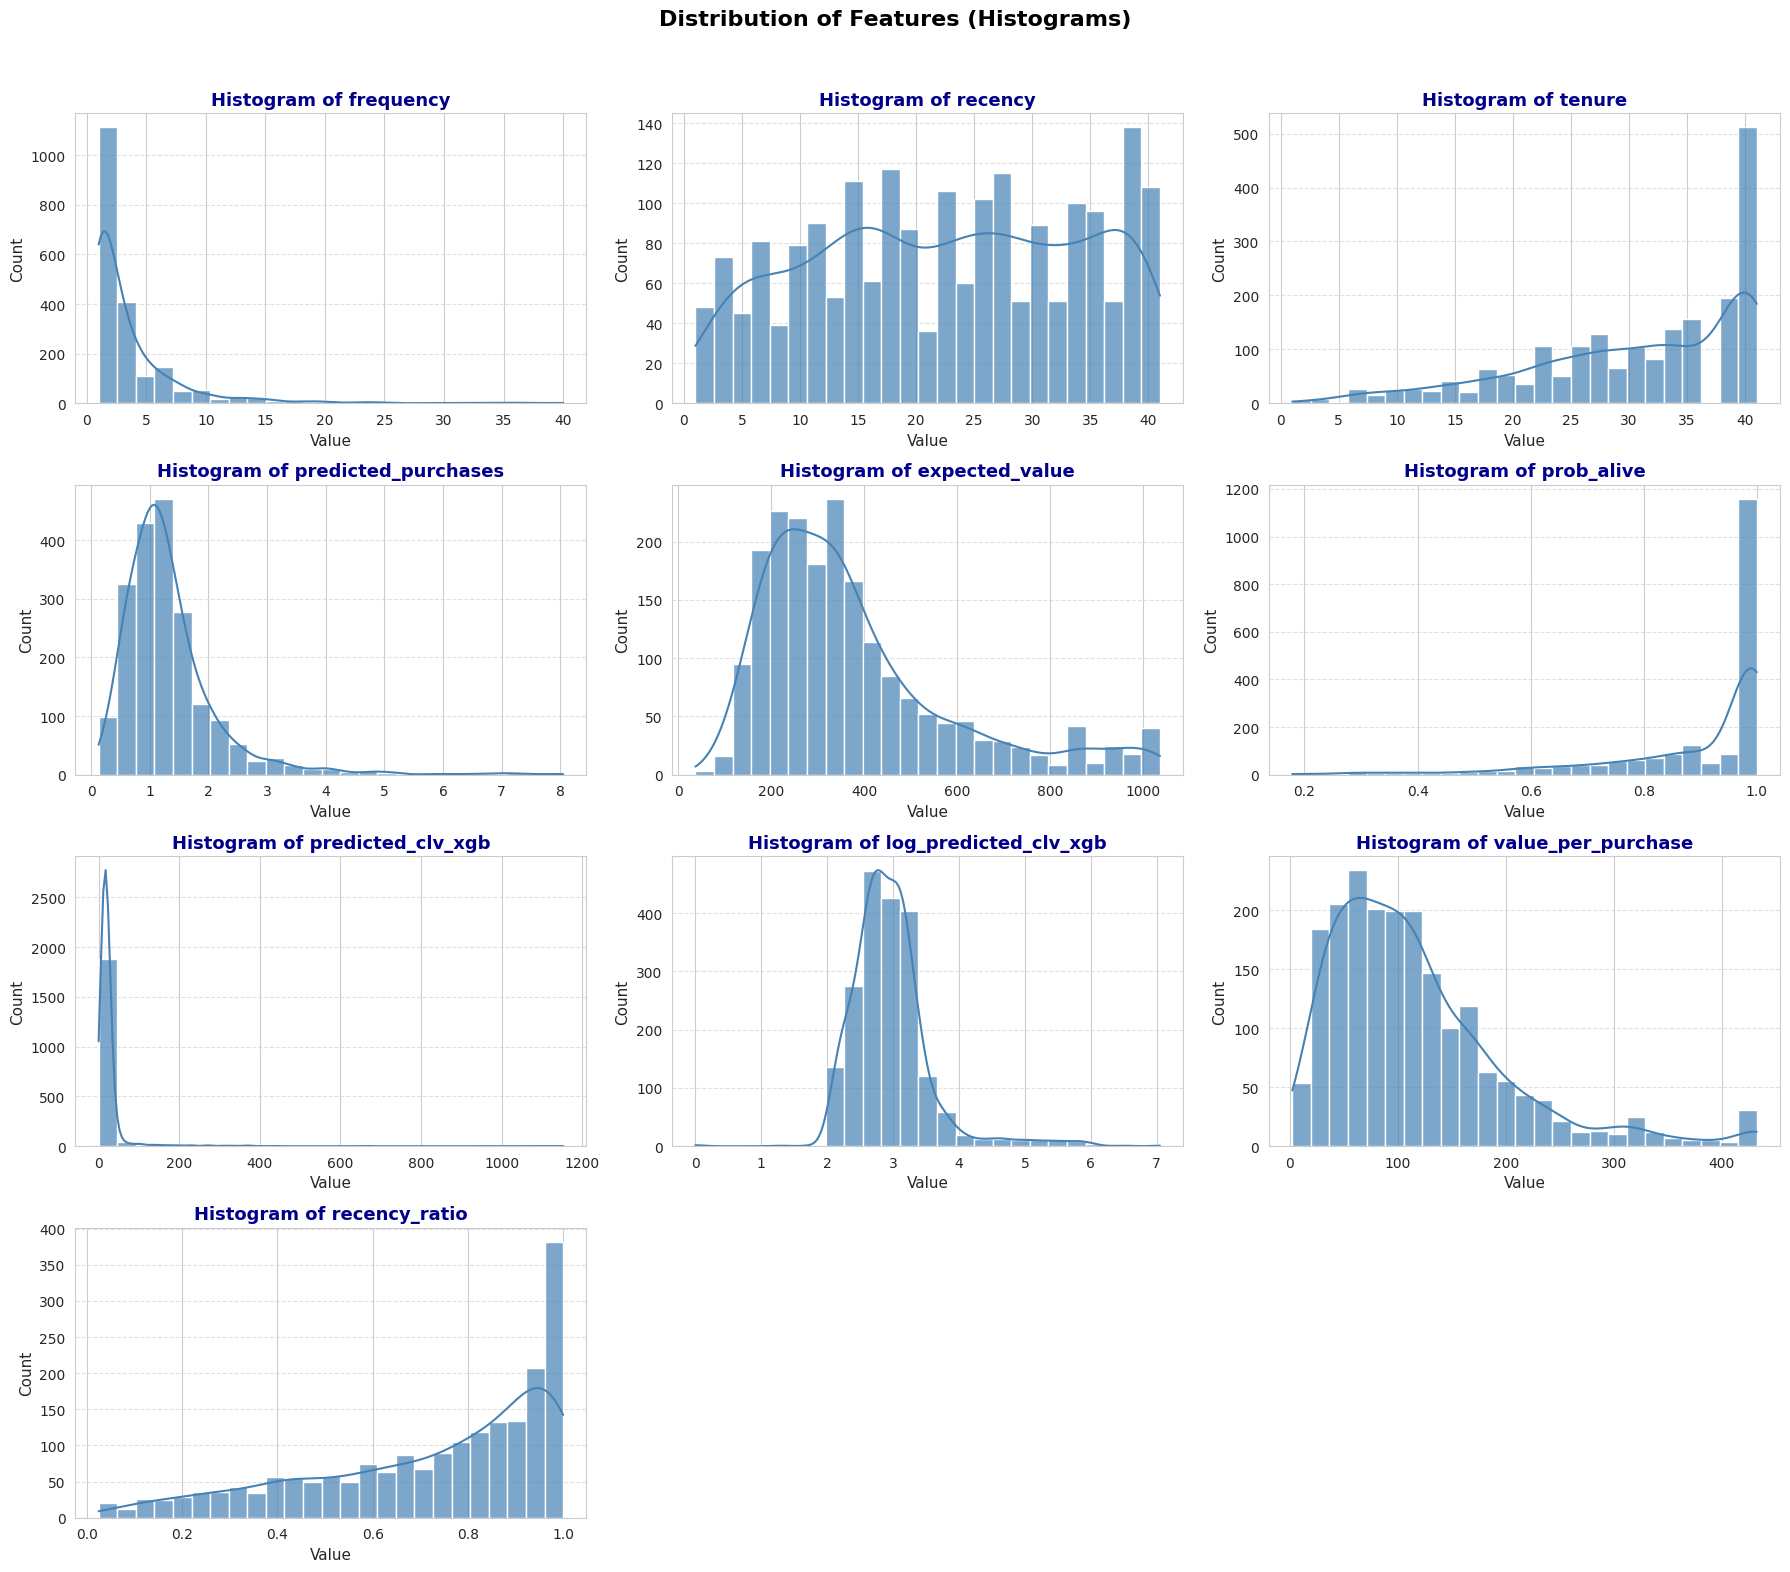

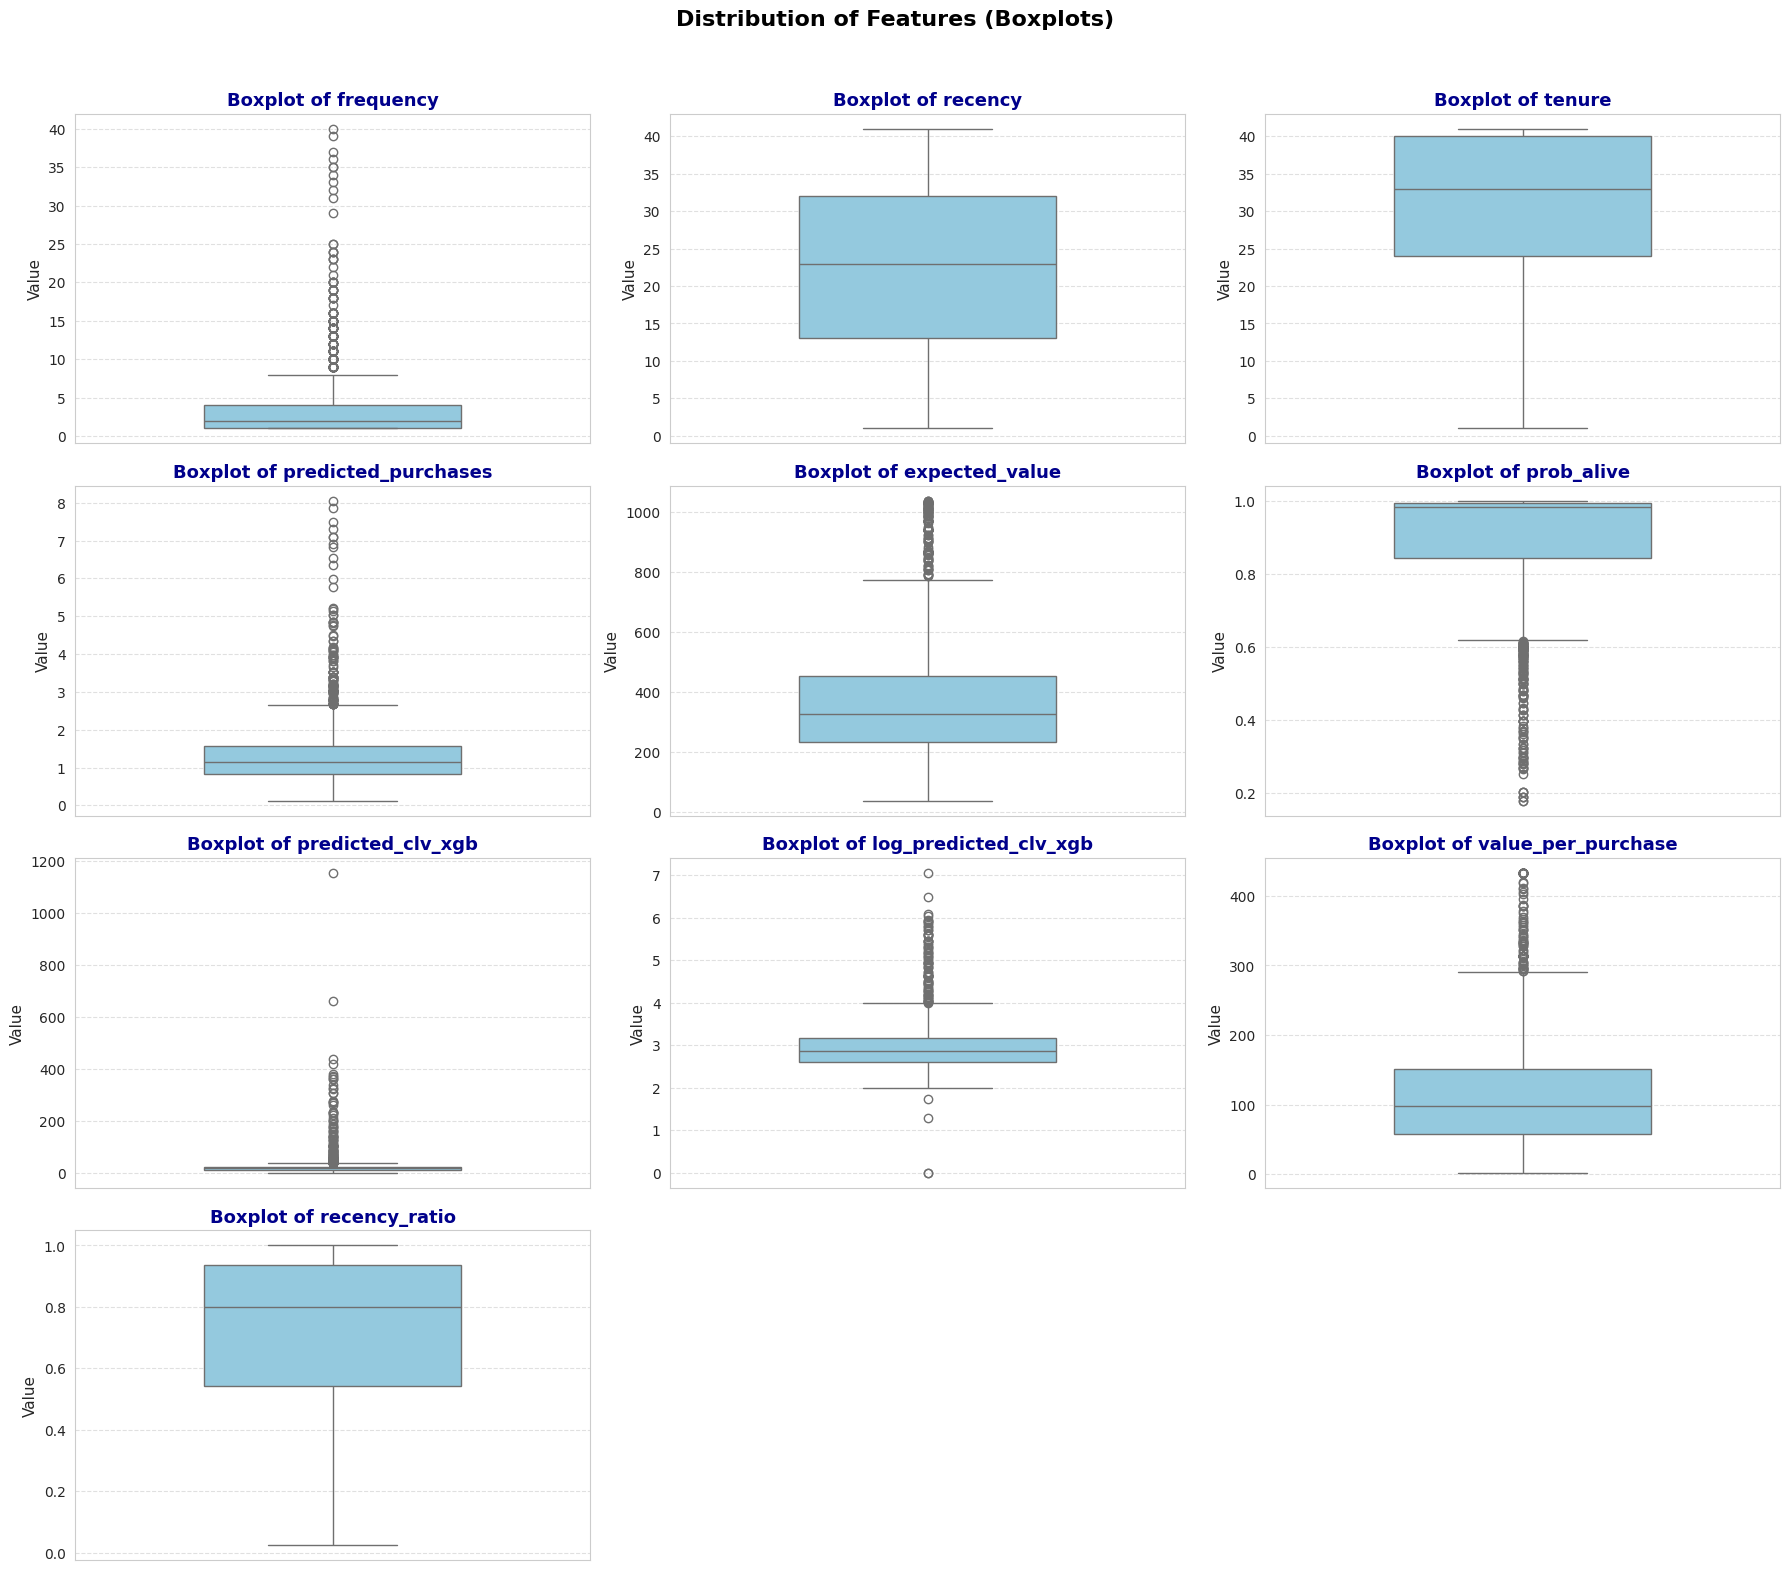

In [133]:
num_features = len(segm_features.columns)
cols_per_row = 3
rows_needed = int(np.ceil(num_features / cols_per_row))

# --- Histograms ---
fig, axes = plt.subplots(rows_needed, cols_per_row, figsize=(18, rows_needed * 4))
axes = axes.flatten()  # flatten to 1D array for easy indexing

for i, col in enumerate(segm_features.columns):
    sns.histplot(segm_features[col], bins=25, kde=True, ax=axes[i],
                 color='steelblue', alpha=0.7)
    axes[i].set_title(f"Histogram of {col}", fontsize=13, fontweight='bold', color='darkblue')
    axes[i].set_xlabel("Value", fontsize=11)
    axes[i].set_ylabel("Count", fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Hide any unused axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Distribution of Features (Histograms)", fontsize=16, fontweight='bold', color='black')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# --- Boxplots ---
fig, axes = plt.subplots(rows_needed, cols_per_row, figsize=(18, rows_needed * 4))
axes = axes.flatten()

for i, col in enumerate(segm_features.columns):
    sns.boxplot(y=segm_features[col], ax=axes[i], color='skyblue', width=0.5)
    axes[i].set_title(f"Boxplot of {col}", fontsize=13, fontweight='bold', color='darkblue')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Value", fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Distribution of Features (Boxplots)", fontsize=16, fontweight='bold', color='black')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class OutlierCapper(BaseEstimator, TransformerMixin):
    """
    Caps outliers in numeric columns based on specified percentiles.

    Parameters
    ----------
    lower_pct : float, default=0.01
        Lower percentile threshold (e.g., 0.01 for 1st percentile).

    upper_pct : float, default=0.99
        Upper percentile threshold (e.g., 0.99 for 99th percentile).
    """
    def __init__(self, lower_pct=0.01, upper_pct=0.99):
        self.lower_pct = lower_pct
        self.upper_pct = upper_pct
        self.lower_bounds_ = None
        self.upper_bounds_ = None

    def fit(self, X, y=None):
        """
        Compute lower and upper bounds for numeric columns.
        """
        if not isinstance(X, pd.DataFrame):
            raise ValueError("X must be a pandas DataFrame.")

        numeric_cols = X.select_dtypes(include='number').columns
        self.lower_bounds_ = X[numeric_cols].quantile(self.lower_pct)
        self.upper_bounds_ = X[numeric_cols].quantile(self.upper_pct)
        return self

    def transform(self, X):
        """
        Cap the outliers in numeric columns.
        """
        if not isinstance(X, pd.DataFrame):
            raise ValueError("X must be a pandas DataFrame.")

        X_capped = X.copy()
        numeric_cols = X.select_dtypes(include='number').columns

        for col in numeric_cols:
            X_capped[col] = X_capped[col].clip(
                lower=self.lower_bounds_[col],
                upper=self.upper_bounds_[col]
            )
        return X_capped


In [134]:
# --- Initialize OutlierCapper ---
capper = OutlierCapper(lower_pct=0.01, upper_pct=0.99)

# --- Fit & transform on features for clustering ---
segm_features_capped = capper.fit_transform(segm_features)

# Optional: keep same column names
segm_features_capped = pd.DataFrame(segm_features_capped, columns=segm_features.columns, index=segm_features.index)

In [138]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(segm_features_capped)

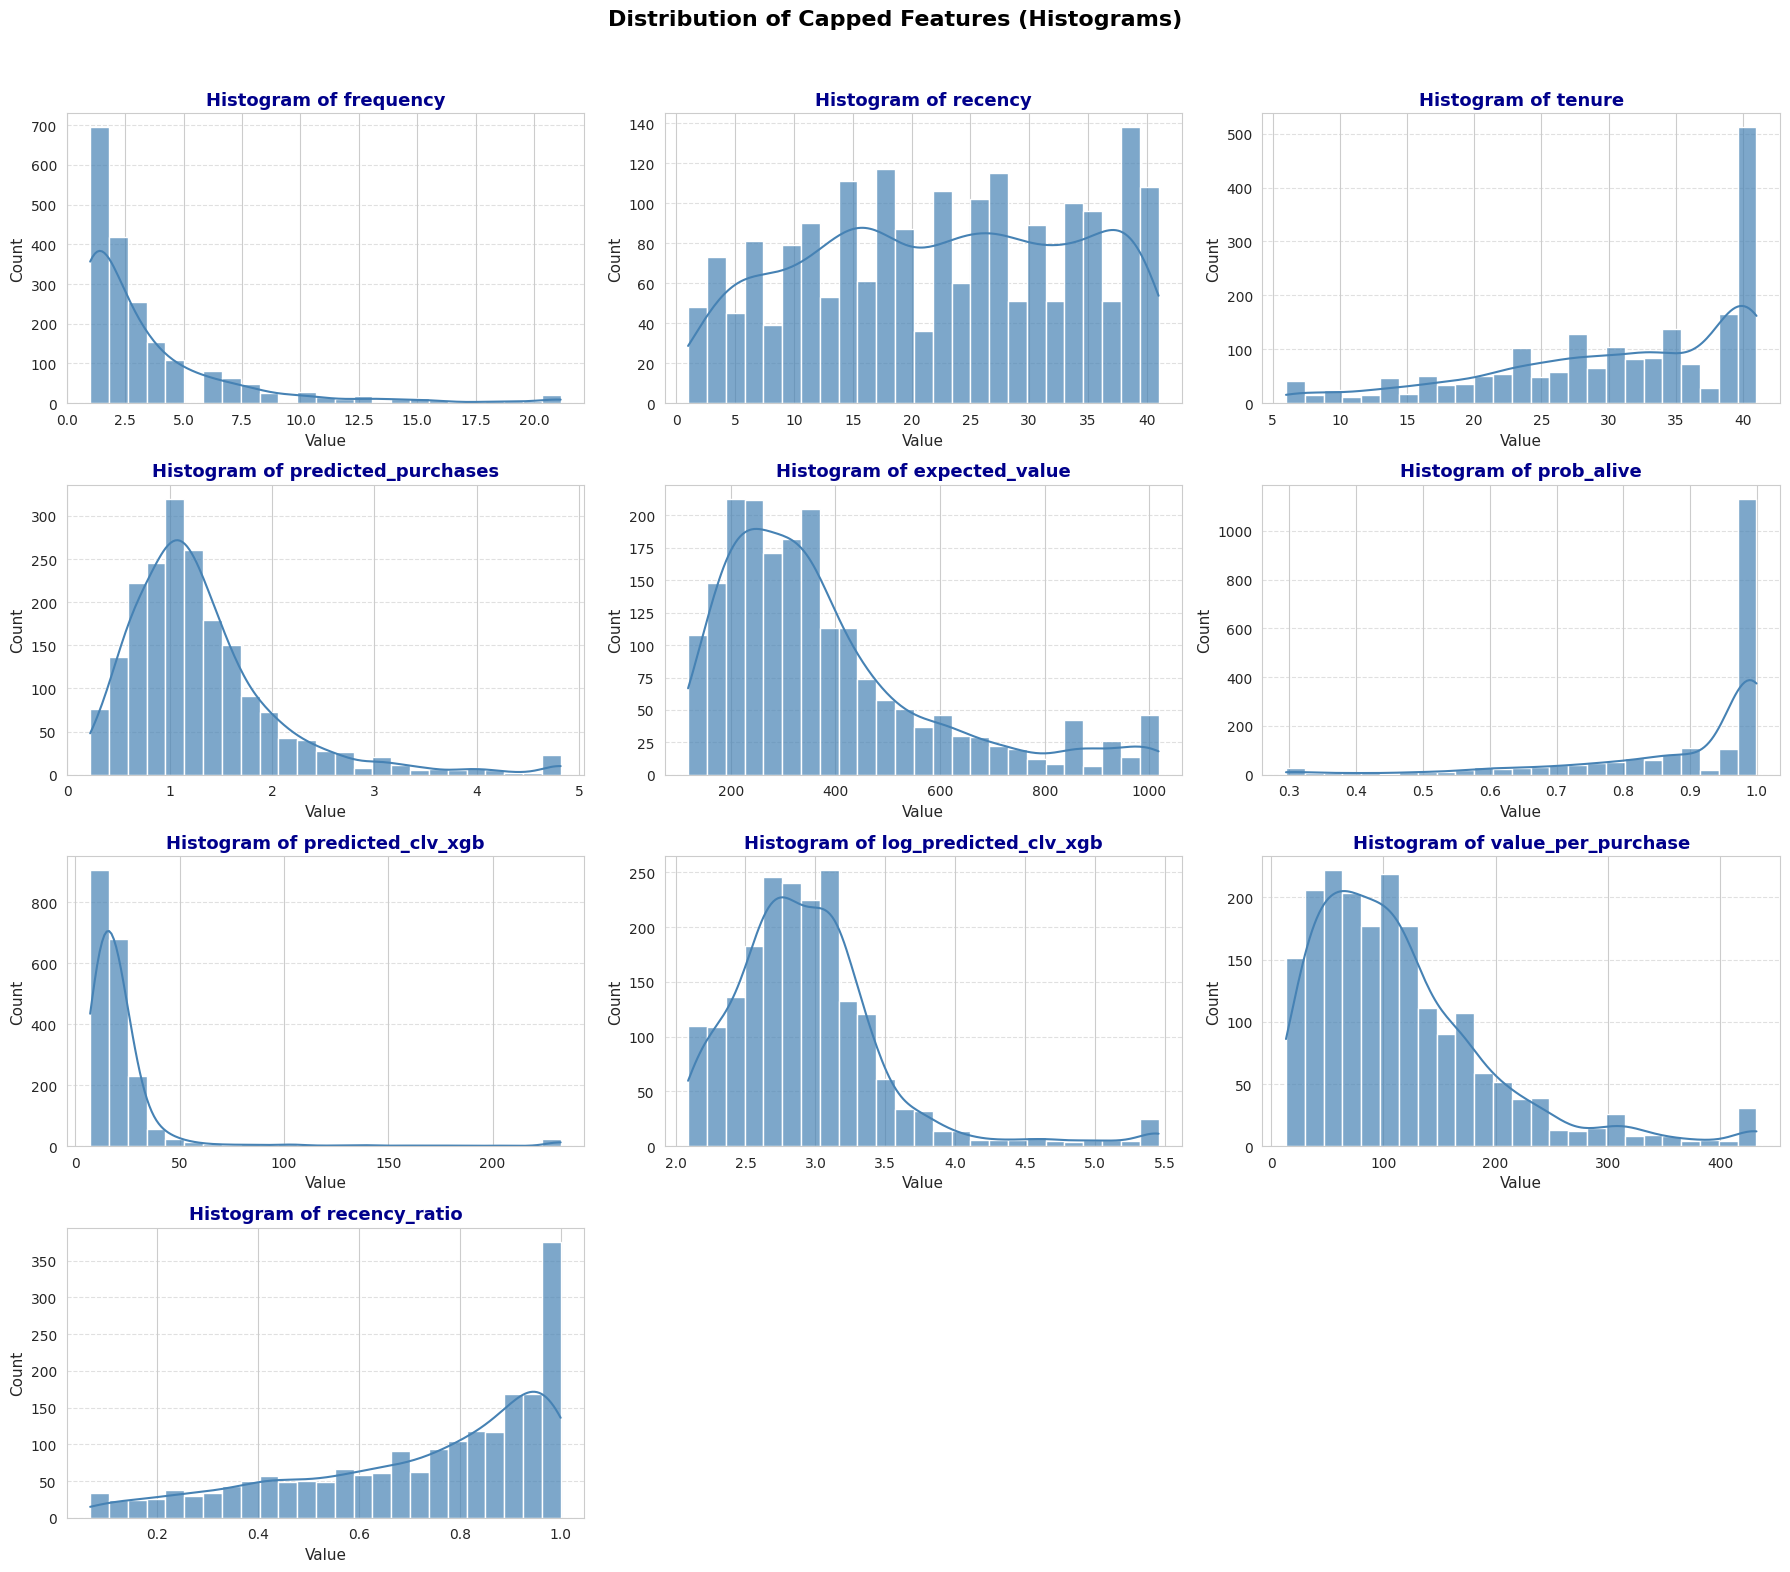

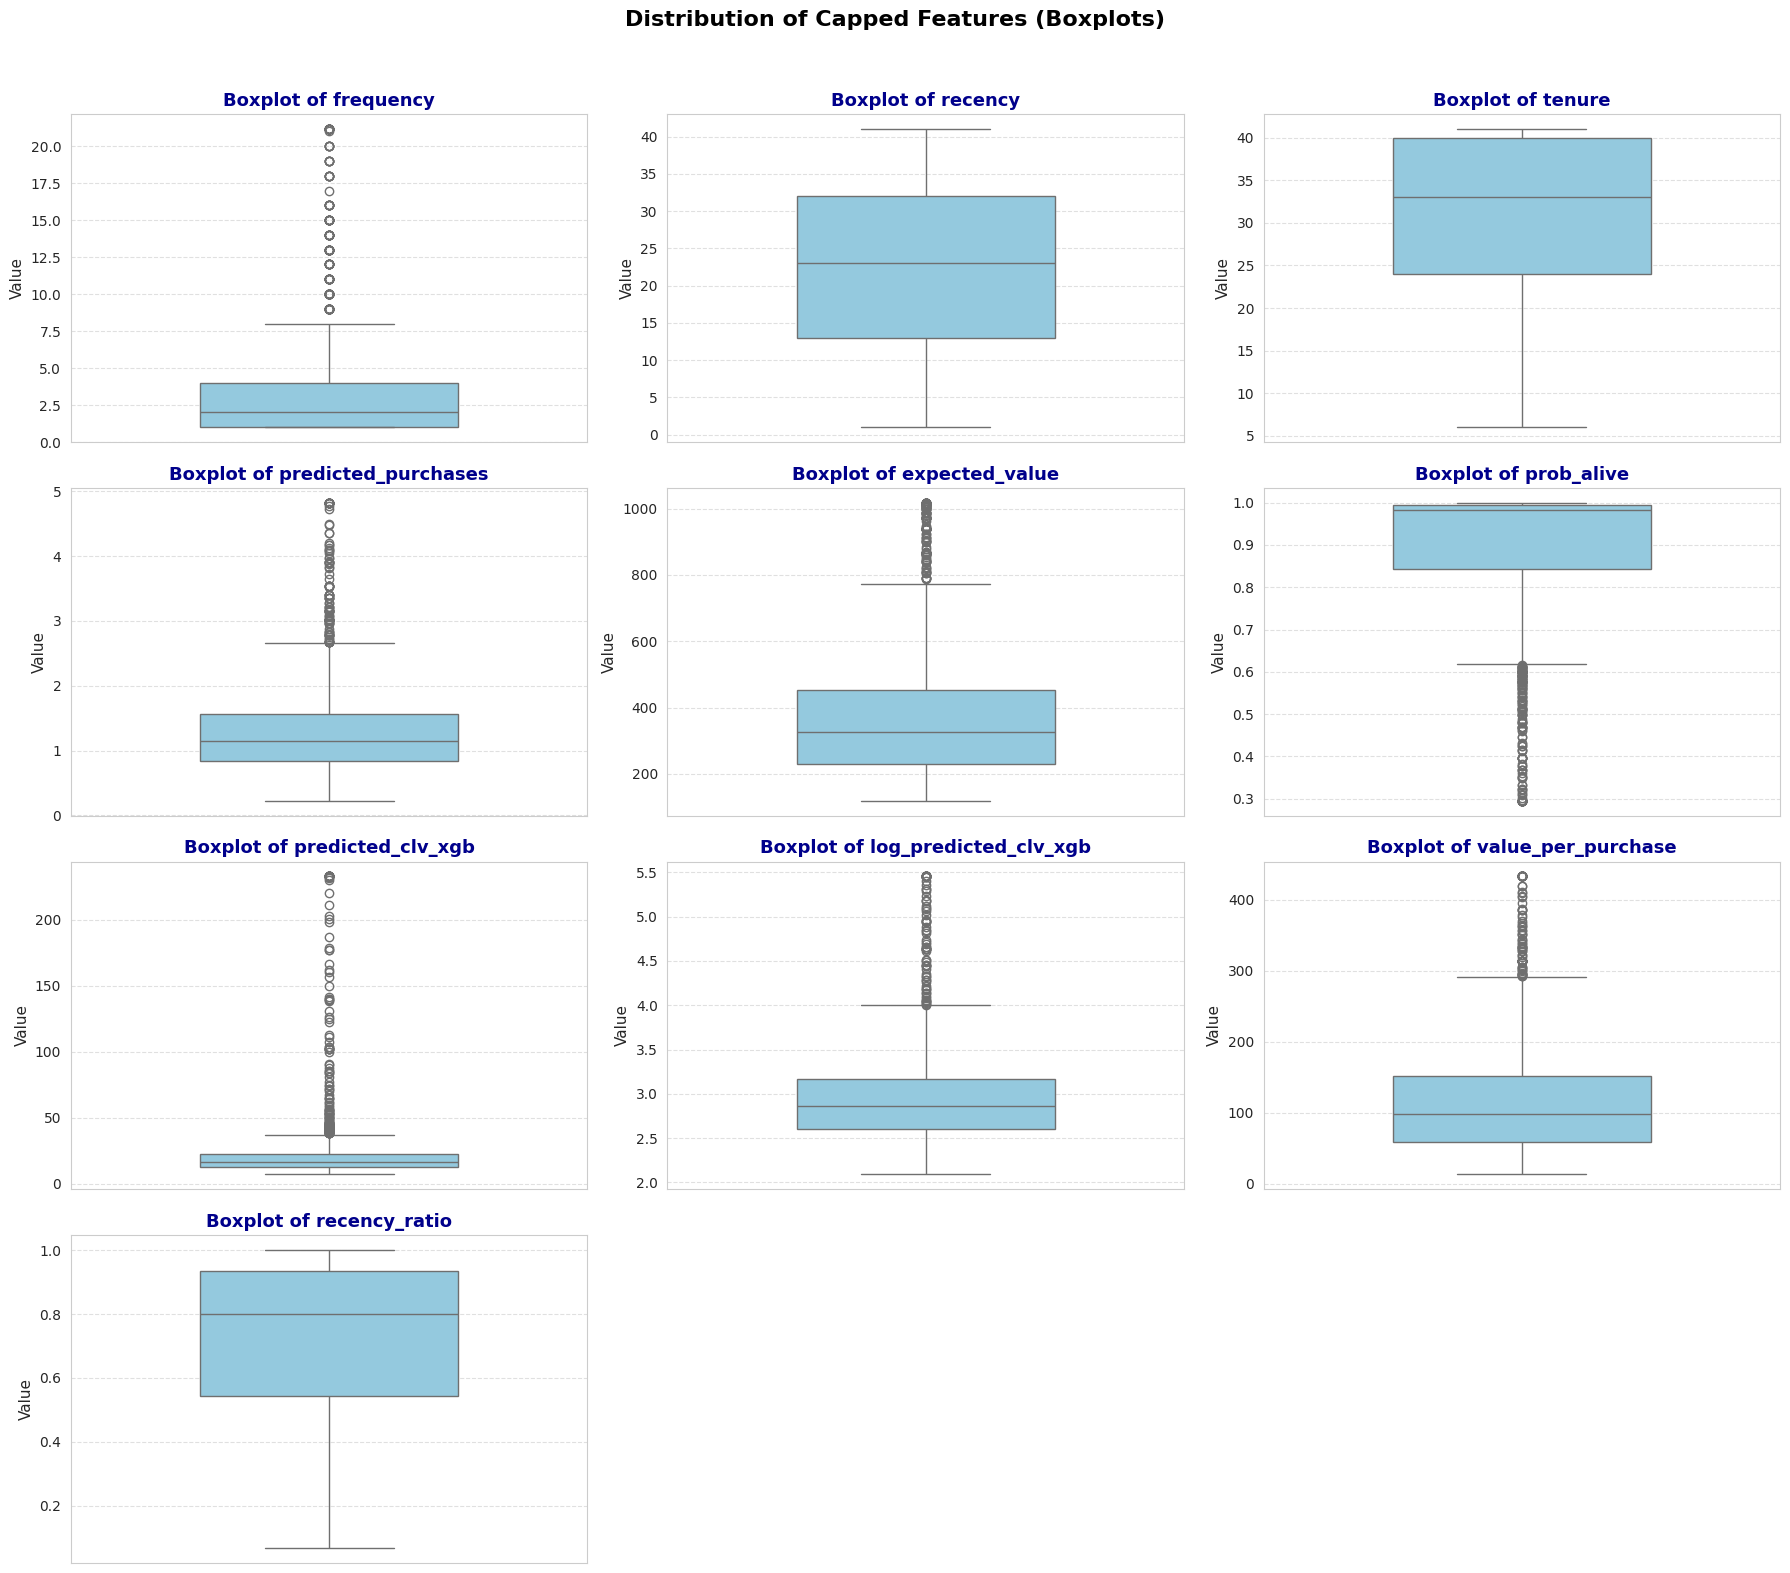

In [139]:
num_features = len(segm_features.columns)
cols_per_row = 3
rows_needed = int(np.ceil(num_features / cols_per_row))

# --- Histograms ---
fig, axes = plt.subplots(rows_needed, cols_per_row, figsize=(18, rows_needed * 4))
axes = axes.flatten()  # flatten to 1D array for easy indexing

for i, col in enumerate(segm_features.columns):
    sns.histplot(segm_features_capped[col], bins=25, kde=True, ax=axes[i],
                 color='steelblue', alpha=0.7)
    axes[i].set_title(f"Histogram of {col}", fontsize=13, fontweight='bold', color='darkblue')
    axes[i].set_xlabel("Value", fontsize=11)
    axes[i].set_ylabel("Count", fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Hide any unused axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Distribution of Capped Features (Histograms)", fontsize=16, fontweight='bold', color='black')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# --- Boxplots ---
fig, axes = plt.subplots(rows_needed, cols_per_row, figsize=(18, rows_needed * 4))
axes = axes.flatten()

for i, col in enumerate(segm_features.columns):
    sns.boxplot(y=segm_features_capped[col], ax=axes[i], color='skyblue', width=0.5)
    axes[i].set_title(f"Boxplot of {col}", fontsize=13, fontweight='bold', color='darkblue')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Value", fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Hide any unused axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Distribution of Capped Features (Boxplots)", fontsize=16, fontweight='bold', color='black')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


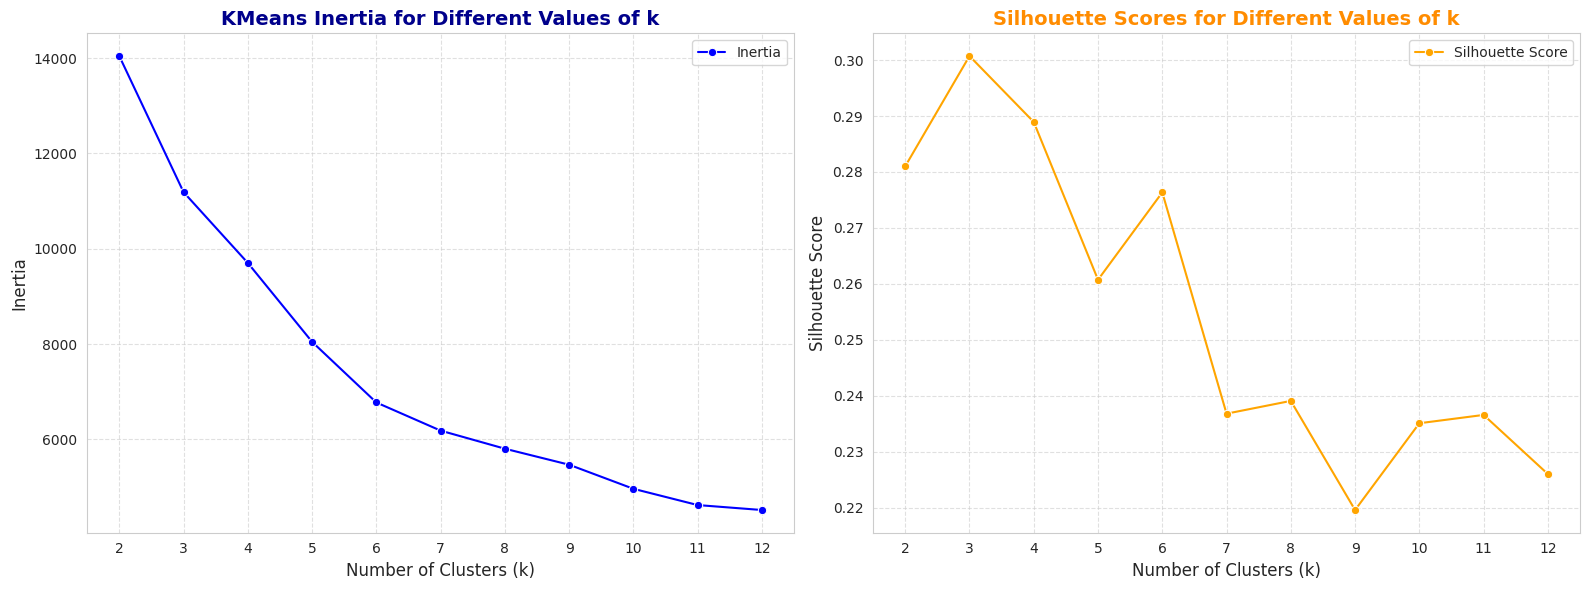

In [140]:
# --- KMeans evaluation ---
max_k = 12
inertia = []
silhouette_scores = []
k_values = range(2, max_k + 1)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000)
    cluster_labels = kmeans.fit_predict(X_scaled)

    sil_score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(sil_score)
    inertia.append(kmeans.inertia_)

# --- Plot results ---
sns.set_style("whitegrid")
sns.set_palette("muted")

plt.figure(figsize=(16, 6))

# Elbow (Inertia) plot
plt.subplot(1, 2, 1)
sns.lineplot(x=k_values, y=inertia, marker='o', color='blue', label='Inertia')
plt.title('KMeans Inertia for Different Values of k', fontsize=14, fontweight='bold', color='darkblue')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.xticks(k_values, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)

# Silhouette plot
plt.subplot(1, 2, 2)
sns.lineplot(x=k_values, y=silhouette_scores, marker='o', color='orange', label='Silhouette Score')
plt.title('Silhouette Scores for Different Values of k', fontsize=14, fontweight='bold', color='darkorange')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(k_values, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()


In [142]:
from sklearn.cluster import KMeans

# Fit KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
segm_df['segment'] = kmeans.fit_predict(X_scaled)


#### Cluster Summary

| Feature                 | Description                                                  | Source                |
| ----------------------- | ------------------------------------------------------------ | --------------------- |
| `frequency`             | Number of repeat purchases during calibration period         | BG/NBD input          |
| `recency`               | Weeks since last purchase during calibration                 | BG/NBD input          |
| `tenure`                | Customer age in weeks (observation period)                   | BG/NBD input          |
| `predicted_purchases`   | Expected number of future transactions                       | BG/NBD output         |
| `expected_value`        | Expected average spend per purchase                          | Gamma–Gamma output    |
| `prob_alive`            | Probability the customer is still active                     | BG/NBD output         |
| `predicted_clv_xgb`     | XGBoost-predicted total CLV                                  | Hybrid/XGBoost output |
| `log_predicted_clv_xgb` | Log-transformed predicted CLV (for scaling or clustering)    | Hybrid/XGBoost output |
| `value_per_purchase`    | Expected value per transaction                               | Derived metric        |
| `recency_ratio`         | Recency divided by tenure (recency relative to customer age) | Derived metric        |


| Segment | Cluster Name                | Key Traits                                                               | Business Interpretation                                                           |
| ------- | --------------------------- | ------------------------------------------------------------------------ | --------------------------------------------------------------------------------- |
| 0       | Mid-Value Customers         | Moderate frequency, medium CLV, high probability_alive                   | Consistent buyers with average value. Focus on nurturing loyalty and upselling.   |
| 1       | Low-Value Occasional Buyers | Low frequency, low CLV, lower probability_alive                          | Low engagement and spending. Consider win-back campaigns or deprioritize.         |
| 2       | VIP Power Buyers            | Very high frequency, highest CLV, top expected value, near-perfect alive | Most valuable customers. Prioritize retention, exclusives, and advocacy programs. |



In [143]:
cluster_summary = segm_df.groupby('segment').agg({
    'frequency': 'mean',
    'recency': 'mean',
    'tenure': 'mean',
    'predicted_purchases': 'mean',
    'expected_value': 'mean',
    'prob_alive': 'mean',
    'predicted_clv_xgb': ['mean', 'sum', 'count'],
    'log_predicted_clv_xgb': 'mean',
    'value_per_purchase': 'mean',
    'recency_ratio': 'mean'
}).round(2)

# Flatten multi-level columns
cluster_summary.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in cluster_summary.columns]
cluster_summary = cluster_summary.reset_index()
cluster_summary





,segment,frequency_mean,recency_mean,tenure_mean,predicted_purchases_mean,expected_value_mean,prob_alive_mean,predicted_clv_xgb_mean,predicted_clv_xgb_sum,predicted_clv_xgb_count,log_predicted_clv_xgb_mean,value_per_purchase_mean,recency_ratio_mean
0,0,4.10,28.85,33.62,1.46,354.83,0.98,20.950001,22652.189453,1081,3.04,86.83,0.86
1,1,1.26,11.33,25.29,0.84,351.49,0.76,13.330000,10317.799805,774,2.58,161.89,0.48
2,2,13.51,35.61,37.79,3.19,753.27,0.99,126.199997,16657.869141,132,4.42,93.36,0.94


In [145]:
segment_names = {
    0: "Mid-Value Customers",
    1: "Low-Value Occasional Buyers",
    2: "VIP Power Buyers"
}

segm_df['segment_name'] = segm_df['segment'].map(segment_names)


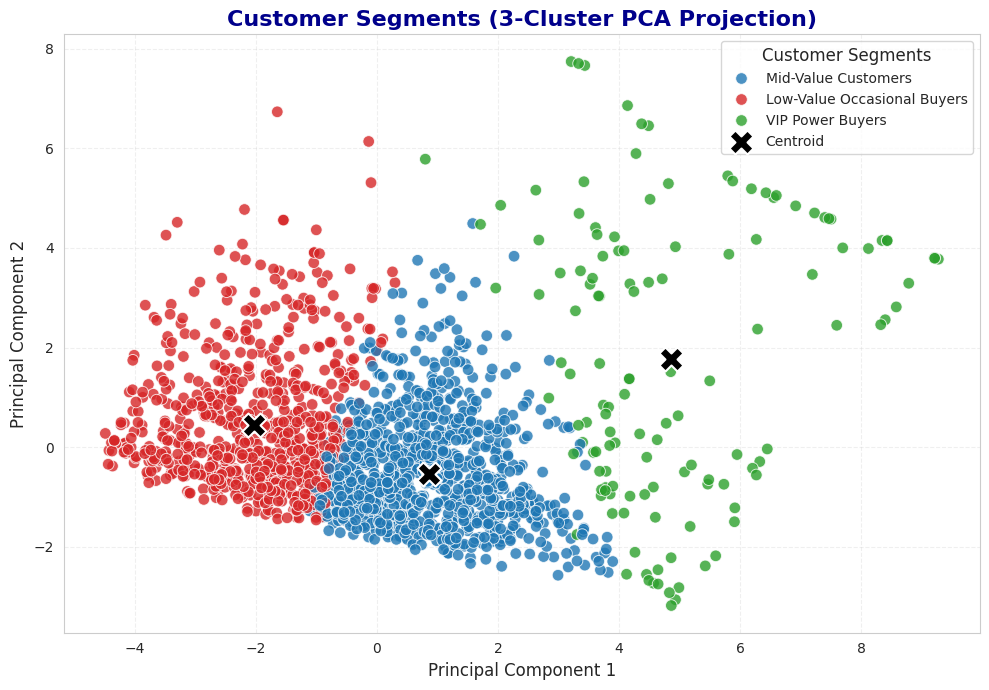

In [146]:
from sklearn.decomposition import PCA
# Assuming X_scaled is the scaled segm_features
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)
segm_df['PCA1'] = pca_result[:, 0]
segm_df['PCA2'] = pca_result[:, 1]

# Color palette
palette = {
    "Mid-Value Customers": "#1f77b4",
    "Low-Value Occasional Buyers": "#d62728",
    "VIP Power Buyers": "#2ca02c"
}

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=segm_df,
    x='PCA1',
    y='PCA2',
    hue='segment_name',
    palette=palette,
    s=70,
    alpha=0.8,
    edgecolor='white'
)

# Add centroids
centroids = segm_df.groupby('segment_name')[['PCA1', 'PCA2']].mean()
plt.scatter(
    centroids['PCA1'], centroids['PCA2'],
    s=300, c='black', marker='X', edgecolors='white', linewidths=1.5, label='Centroid'
)

plt.title("Customer Segments (3-Cluster PCA Projection)", fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.legend(title='Customer Segments', title_fontsize=12, fontsize=10, loc='best', frameon=True)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
